# Deep Learning - Clasificación de Lesiones Cutáneas

**Autores:** David Moreda Amezcua, Javier Cerón Contreras, Pedro Martínez Huertas

**Máster en Inteligencia Artificial - Universidad Loyola**

## 1. Preparación de Datos y Prevención de Data Leakage

### 1.1 Estructura del Proyecto

Este proyecto se divide en **tres bloques de experimentación**:
- **Bloque A**: Modelos Unimodales con Deep Learning (solo imágenes)
- **Bloque B**: Modelos Unimodales con Machine Learning (solo datos tabulares)
- **Bloque C**: Modelos Híbridos (combinación de imágenes + datos tabulares)

### 1.2 Split Train/Test Común

Para garantizar una **comparación justa** entre las diferentes aproximaciones y evitar **data leakage** entre bloques, se ha definido un split común de train/test a nivel de proyecto:

- Los datos se dividen utilizando `Train_clean.csv` y `Test_clean.csv`
- **Todos los bloques** utilizan exactamente las mismas imágenes en train y test
- Esto asegura que los resultados de DL, ML e híbridos sean comparables entre sí

### 1.3 Organización del Dataset

Se trabaja con dos configuraciones del problema:

**Clasificación Multiclase (6 clases)**:
- ACK (Queratosis Actínica)
- BCC (Carcinoma Basocelular)
- MEL (Melanoma)
- NEV (Nevus)
- SCC (Carcinoma de Células Escamosas)
- SEK (Queratosis Seborreica)

**Clasificación Binaria (2 clases)**:
- Benigno (ACK, NEV, SEK)
- Maligno (BCC, MEL, SCC)

### 1.4 Estructura de Directorios
```
Datos/images/
├── SPLIT_MULTICLASE/
│   ├── train/
│   │   ├── ACK/
│   │   ├── BCC/
│   │   ├── MEL/
│   │   ├── NEV/
│   │   ├── SCC/
│   │   └── SEK/
│   └── test/
│       ├── ACK/
│       ├── BCC/
│       ├── MEL/
│       ├── NEV/
│       ├── SCC/
│       └── SEK/
│
└── SPLIT_BINARIO/
    ├── train/
    │   ├── Benigno/
    │   └── Maligno/
    └── test/
        ├── Benigno/
        └── Maligno/
```
### 1.5 Importancia del Split Único
El uso de un **split común** es crítico porque:
1. **Evita data leakage**: Una imagen que está en train en el bloque DL no puede estar en test en el bloque ML
2. **Permite comparación directa**: Los tres bloques se evalúan sobre exactamente las mismas muestras de test
3. **Garantiza reproducibilidad**: Cualquier miembro del equipo trabaja con los mismos datos
4. **Validación cruzada consistente**: El 5-fold CV se aplica solo sobre el conjunto de train, sin contaminar test
Este enfoque metodológico asegura que las conclusiones del proyecto sobre qué aproximación funciona mejor (DL vs ML vs Híbrido) sean **estadísticamente válidas y comparables**.

In [1]:
import os
import pandas as pd
import shutil

BASE = "/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos"
IMG_SRC = os.path.join(BASE, "images", "MULTICLASE")
IMG_DST = os.path.join(BASE, "images", "SPLIT_MULTICLASE")

df_train = pd.read_csv(os.path.join(BASE, "Train_clean.csv"))
df_test = pd.read_csv(os.path.join(BASE, "Test_clean.csv"))

class_names = {0: "ACK", 1: "BCC", 2: "MEL", 3: "NEV", 4: "SCC", 5: "SEK"}
binary_names = {0: "Benigno", 1: "Maligno"}
splits = {"train": df_train, "test": df_test}



for split_name in splits:
    for class_name in class_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name), exist_ok=True)
    for bin_name in binary_names.values():
        os.makedirs(os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name), exist_ok=True)

for split_name, df in splits.items():
    for _, row in df.iterrows():
        diag = row["diagnostic"]
        diag_bin = row["diagnostic_binario"]
        multi_name = class_names[diag]
        bin_name = binary_names[diag_bin]

        for img_name in str(row["img_id"]).split(", "):
            img_name = img_name.strip()
            src = os.path.join(IMG_SRC, multi_name, img_name)
            if not os.path.exists(src):
                print(f"No encontrada: {src}")
                continue
            dst_multi = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, multi_name, img_name)
            shutil.copy2(src, dst_multi)
            dst_bin = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name, img_name)
            shutil.copy2(src, dst_bin)
print("=== MULTICLASE ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for class_name in class_names.values():
        path = os.path.join(BASE, "images", "SPLIT_MULTICLASE", split_name, class_name)
        print(f"  {class_name}: {len(os.listdir(path))}")

print("\n=== BINARIO ===")
for split_name in splits:
    print(f"\n{split_name}:")
    for bin_name in binary_names.values():
        path = os.path.join(BASE, "images", "SPLIT_BINARIO", split_name, bin_name)
        print(f"  {bin_name}: {len(os.listdir(path))}")


=== MULTICLASE ===

train:
  ACK: 120
  BCC: 118
  MEL: 44
  NEV: 122
  SCC: 123
  SEK: 122

test:
  ACK: 30
  BCC: 32
  MEL: 8
  NEV: 28
  SCC: 27
  SEK: 28

=== BINARIO ===

train:
  Benigno: 364
  Maligno: 285

test:
  Benigno: 86
  Maligno: 67


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Objetivo del Análisis

El análisis exploratorio tiene tres objetivos principales:

1. **Evaluar la distribución de clases** para identificar posibles desbalances que requieran tratamiento especial
2. **Analizar las dimensiones de las imágenes** para definir el pipeline de preprocesamiento óptimo
3. **Validar la consistencia** del split train/test en ambos conjuntos

### 2.2 Distribución de Clases

**Train: 649 imágenes** | **Test: 153 imágenes**

| Clase | Train      | Test       |
|-------|------------|------------|
| ACK   | 120 (18.5%)| 30 (19.6%) |
| BCC   | 118 (18.2%)| 32 (20.9%) |
| MEL   | 44 (6.8%)  | 8 (5.2%) ⚠️|
| NEV   | 122 (18.8%)| 28 (18.3%) |
| SCC   | 123 (19.0%)| 27 (17.6%) |
| SEK   | 122 (18.8%)| 28 (18.3%) |

### 2.3 Análisis de Dimensiones

**Estadísticas de tamaño:**
- Tamaño medio: **890x890 px**
- Rango: **147x147** hasta **3474x3476 px**
- Relación de aspecto: **~1:1** (imágenes cuadradas)

**Observaciones clave:**
- Las imágenes mantienen una proporción cuadrada consistente (puntos alineados en la diagonal)
- La variabilidad de tamaño (147-3474 px) requiere normalización mediante resize
- El objetivo de **224x224** es compatible con arquitecturas pretrenadas (ResNet, DenseNet, YOLO)

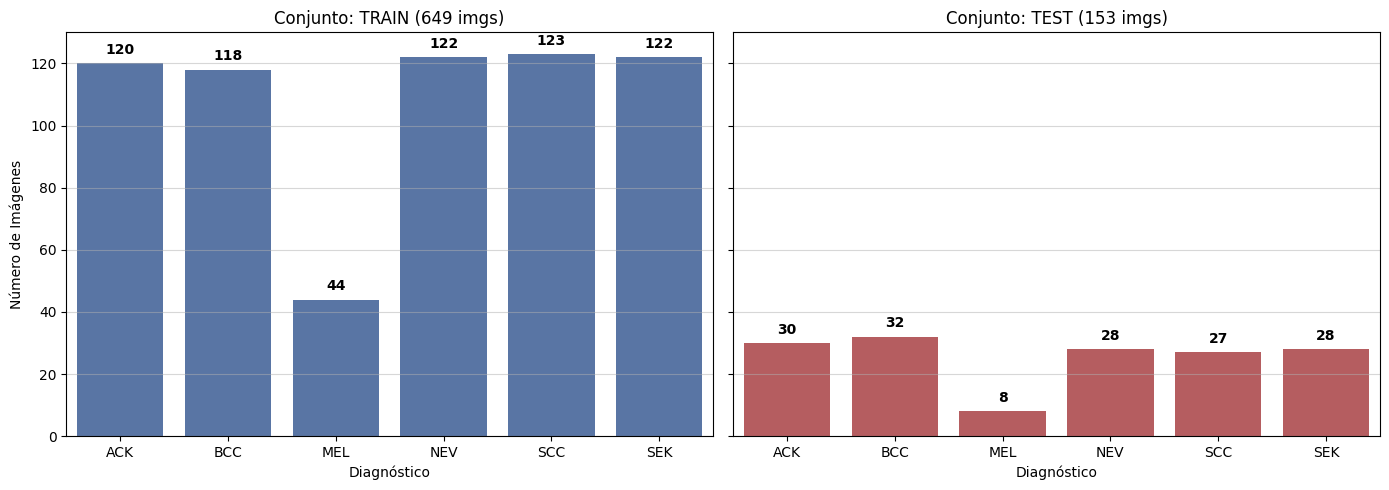


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


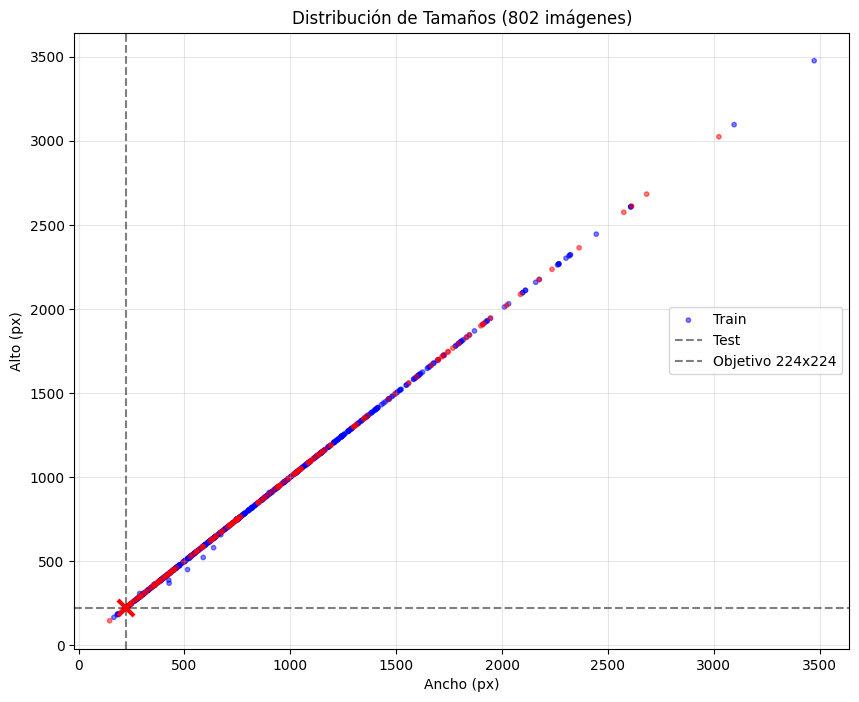

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm

RUTA_RAIZ = "../../Datos/images/SPLIT_MULTICLASE"
splits = ["train", "test"]
colores = ["#4c72b0", "#c44e52"]

# --- Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, split in enumerate(splits):
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    conteo = {c: len(os.listdir(os.path.join(split_path, c))) for c in clases}
    total = sum(conteo.values())

    sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), ax=axes[i], color=colores[i])
    axes[i].set_title(f"Conjunto: {split.upper()} ({total} imgs)")
    axes[i].set_xlabel("Diagnóstico")
    axes[i].grid(axis="y", alpha=0.5)
    axes[i].set_ylim(0, 130)

    for idx, (clase, valor) in enumerate(conteo.items()):
        axes[i].text(idx, valor + 3, str(valor), ha="center", fontweight="bold")

axes[0].set_ylabel("Número de Imágenes")
plt.tight_layout()
plt.show()

# --- Tamaño de imágenes ---
anchos = []
altos = []
colores_puntos = []
mapa_colores = {"train": "blue", "test": "red"}

for split in splits:
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    for clase in clases:
        clase_path = os.path.join(split_path, clase)
        archivos = [f for f in os.listdir(clase_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for nombre in tqdm(archivos, desc=f"{split}/{clase}", leave=False):
            ruta_completa = os.path.join(clase_path, nombre)
            with Image.open(ruta_completa) as img:
                w, h = img.size
                anchos.append(w)
                altos.append(h)
                colores_puntos.append(mapa_colores[split])

plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)
plt.axvline(224, color="k", linestyle="--", alpha=0.5)
plt.axhline(224, color="k", linestyle="--", alpha=0.5)
plt.plot(224, 224, "rx", markersize=12, markeredgewidth=3)
plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(["Train", "Test", "Objetivo 224x224"])
plt.grid(True, alpha=0.3)

print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()


### Conclusiones del EDA y Estrategia de Evaluación

**1. Análisis del Dataset**

- **Desbalanceo Crítico:** Se identifica un desbalanceo significativo donde la clase MEL (Melanoma) representa solo el **6.8% del train** y **5.2% del test**. Esto presenta un desafío importante, ya que induce al modelo a sesgar sus predicciones hacia las clases mayoritarias, ignorando los casos positivos de melanoma.

- **Volumen de Datos Limitado:** El conjunto de entrenamiento contiene **649 imágenes**, un volumen insuficiente para entrenar redes profundas desde cero sin riesgo de overfitting. Esto hace imprescindible el uso de **Transfer Learning** y un **Data Augmentation** robusto.

- **Consistencia en Dimensiones:** Las imágenes mantienen proporciones cuadradas similares, validando el redimensionado directo a **224x224 px** sin pérdida significativa de información morfológica.

- **Consistencia Train/Test:** La distribución de clases se mantiene proporcionalmente similar entre train y test, lo que garantiza que el conjunto de test es representativo del problema real.

**2. Estrategia de Evaluación Clínica**

Debido a la naturaleza médica del problema y al desbalanceo de clases, la métrica de **Accuracy** global se descarta como indicador principal. La evaluación se basará en:

- **F1-Score Macro:** Métrica principal de optimización. Al promediar el rendimiento por clase sin ponderar por número de muestras, penaliza fuertemente al modelo si falla en la detección de MEL, obligándolo a generalizar correctamente en todos los diagnósticos.

- **Sensibilidad (Recall) para MEL:** Desde una perspectiva clínica, la prioridad es minimizar los **falsos negativos**. Un alto Recall en la clase Melanoma garantiza que se detecten la mayor cantidad posible de casos malignos, priorizando la seguridad del paciente.

- **Matriz de Confusión:** Permite analizar los patrones de error específicos y entender con qué lesiones benignas se confunde el melanoma (ej. NEV vs MEL).

- **AUC-ROC (One-vs-All):** Se evaluará el área bajo la curva ROC para cada clase mediante estrategia **one-vs-all**, permitiendo analizar la capacidad de discriminación del modelo para distinguir cada diagnóstico específico del resto de lesiones.

## 3. Hiperparametrización con Optuna

### 3.1 Búsqueda de Hiperparámetros

Se utilizó **Optuna** para optimización automática de hiperparámetros mediante optimización bayesiana. El framework implementa **pruning dinámico** (MedianPruner) que detiene trials poco prometedores tras cada fold, ahorrando tiempo de cómputo. Cada configuración se evalúa con **5-Fold Cross-Validation** estratificado.

**Métrica objetivo** (todos los modelos): `score = 0.5 × F1_Macro + 0.5 × Cohen_Kappa`

### 3.2 Modelos y Transfer Learning

Tras experimentación empírica se seleccionaron **ResNet18**, **DenseNet121** y **YOLO26x**.

**Estrategia de congelación:**
- **ResNet18/DenseNet121**: Se congelan capas iniciales (features de ImageNet) y solo se entrenan las últimas capas específicas del dominio
- **YOLO26x**: Sin congelación (`freeze=0`) ya que sus capas están altamente acopladas y congelar reduce significativamente el performance

### 3.3 Hiperparámetros Optimizados

**ResNet18/DenseNet121**: `lr_backbone`, `lr_head`, `weight_decay`, `dropout`, `batch_size`

**YOLO26x**: `lr0`, `lrf`, `momentum`, `weight_decay`, `dropout`, `optimizer`, `batch_size`

**Configuración**: 20 trials por modelo, ~25 épocas por trial, almacenamiento en SQLite para persistencia

📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS

🔍 Cargando estudios de Optuna...
  ✅ ResNet18: 20 trials
  ✅ DenseNet121: 20 trials
  ✅ YOLO26x: 30 trials

📈 Generando gráfica: Evolución de scores...



🎨 Generando gráficas: Combinaciones de hiperparámetros...


  ✅ ResNet18


  ✅ DenseNet121


  ✅ YOLO26x

📊 ESTADÍSTICAS DE TRIALS

     Modelo  Total Trials  Completados  Podados  Fallidos % Completados
   ResNet18            20           12        8         0         60.0%
DenseNet121            20           17        3         0         85.0%
    YOLO26x            30           10       20         0         33.3%

🏆 MEJORES HIPERPARÁMETROS POR MODELO

────────────────────────────────────────────────────────────────────────────────
📌 RESNET18
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.5600
🔢 Mejor Trial: #0

📝 Hiperparámetros:
   • batch_size          : 16
   • dropout             : 0.300000
   • lr_backbone         : 0.000131
   • lr_head             : 0.000437
   • weight_decay        : 0.002365

────────────────────────────────────────────────────────────────────────────────
📌 DENSENET121
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.5550
🔢 Mejor Trial: #14

📝 Hiperp

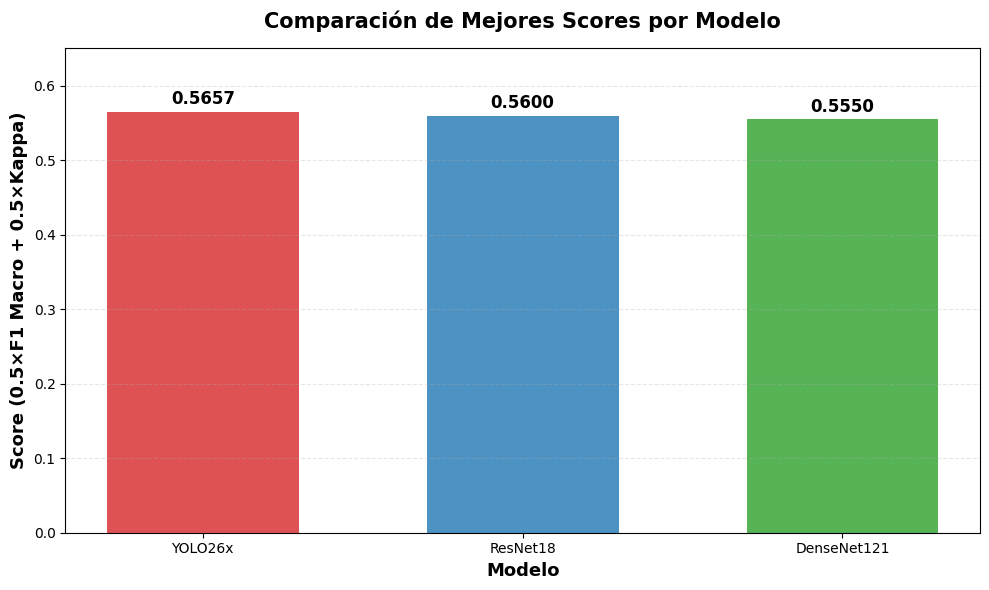


✅ VISUALIZACIÓN COMPLETADA



In [2]:
"""
Visualización de hiperparametrización - ResNet18, DenseNet121, YOLO26x
"""

import optuna
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configuración
DB_RESNET_DENSENET = "hyperparameters/hyperparameter_tuning.db"
DB_YOLO = "hyperparameters/yolo_tuning.db"

print("="*80)
print("📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS")
print("="*80)

# ============================================================================
# 1. CARGAR ESTUDIOS
# ============================================================================

print("\n🔍 Cargando estudios de Optuna...")

storage_resnet = f"sqlite:///{DB_RESNET_DENSENET}"
try:
    study_resnet = optuna.load_study(study_name="resnet18_tuning", storage=storage_resnet)
    print(f"  ✅ ResNet18: {len(study_resnet.trials)} trials")
except:
    print(f"  ❌ ResNet18 no encontrado")
    study_resnet = None

try:
    study_densenet = optuna.load_study(study_name="densenet121_tuning", storage=storage_resnet)
    print(f"  ✅ DenseNet121: {len(study_densenet.trials)} trials")
except:
    print(f"  ❌ DenseNet121 no encontrado")
    study_densenet = None

storage_yolo = f"sqlite:///{DB_YOLO}"
try:
    study_yolo = optuna.load_study(study_name="yolo26x-cls_tuning", storage=storage_yolo)
    print(f"  ✅ YOLO26x: {len(study_yolo.trials)} trials")
except:
    print(f"  ❌ YOLO26x no encontrado")
    study_yolo = None

def get_completed_trials(study):
    if study is None:
        return []
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

# ============================================================================
# 2. GRÁFICA: EVOLUCIÓN DE SCORES
# ============================================================================

print("\n📈 Generando gráfica: Evolución de scores...")

studies = {
    'ResNet18': study_resnet,
    'DenseNet121': study_densenet,
    'YOLO26x': study_yolo
}

colors = {'ResNet18': '#1f77b4', 'DenseNet121': '#2ca02c', 'YOLO26x': '#d62728'}

fig = go.Figure()

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    trial_numbers = [t.number for t in completed]
    scores = [t.value for t in completed]
    
    # Trials
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=scores,
        mode='markers+lines',
        name=f'{model_name}',
        marker=dict(size=8, color=colors[model_name]),
        line=dict(color=colors[model_name], width=2, dash='dot'),
        opacity=0.6
    ))
    
    # Best so far
    best_so_far = []
    current_best = -float('inf')
    for score in scores:
        current_best = max(current_best, score)
        best_so_far.append(current_best)
    
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=best_so_far,
        mode='lines',
        name=f'{model_name} (best)',
        line=dict(color=colors[model_name], width=3),
        opacity=0.9
    ))

fig.update_layout(
    title='Evolución de Scores en Hiperparametrización',
    xaxis_title='Trial Number',
    yaxis_title='Score (0.5×F1 Macro + 0.5×Kappa)',
    hovermode='closest',
    template='plotly_white',
    height=600,
    font=dict(size=12)
)
fig.show()

# ============================================================================
# 3. GRÁFICAS: PARALLEL COORDINATES (Combinaciones de hiperparámetros)
# ============================================================================

print("\n🎨 Generando gráficas: Combinaciones de hiperparámetros...")

for model_name, study in studies.items():
    if study is None or len(get_completed_trials(study)) < 3:
        continue
    
    try:
        fig = optuna.visualization.plot_parallel_coordinate(study)
        fig.update_layout(
            title=f'Combinaciones de Hiperparámetros - {model_name}',
            height=500
        )
        fig.show()
        print(f"  ✅ {model_name}")
    except Exception as e:
        print(f"  ⚠️  Error en {model_name}: {e}")

# ============================================================================
# 4. TABLA: ESTADÍSTICAS DE TRIALS
# ============================================================================

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DE TRIALS")
print("="*80)

stats_data = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    total = len(study.trials)
    pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    failed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.FAIL)
    
    stats_data.append({
        'Modelo': model_name,
        'Total Trials': total,
        'Completados': len(completed),
        'Podados': pruned,
        'Fallidos': failed,
        '% Completados': f"{len(completed)/total*100:.1f}%"
    })

df_stats = pd.DataFrame(stats_data)
print("\n" + df_stats.to_string(index=False))

# ============================================================================
# 5. RESUMEN: MEJORES HIPERPARÁMETROS
# ============================================================================

print("\n" + "="*80)
print("🏆 MEJORES HIPERPARÁMETROS POR MODELO")
print("="*80)

results_summary = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    best_trial = study.best_trial
    
    print(f"\n{'─'*80}")
    print(f"📌 {model_name.upper()}")
    print(f"{'─'*80}")
    print(f"🏆 Mejor Score: {best_trial.value:.4f}")
    print(f"🔢 Mejor Trial: #{best_trial.number}")
    print(f"\n📝 Hiperparámetros:")
    
    for param, value in sorted(best_trial.params.items()):
        if isinstance(value, float):
            print(f"   • {param:20s}: {value:.6f}")
        else:
            print(f"   • {param:20s}: {value}")
    
    results_summary.append({
        'Modelo': model_name,
        'Score': best_trial.value
    })

# ============================================================================
# 6. GRÁFICA: COMPARACIÓN DE SCORES (MATPLOTLIB)
# ============================================================================

if results_summary:
    print("\n" + "="*80)
    print("📊 COMPARACIÓN FINAL")
    print("="*80)
    
    df = pd.DataFrame(results_summary).sort_values('Score', ascending=False)
    print("\n" + df.to_string(index=False))
    
    # Gráfica con matplotlib
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bar_colors = [colors.get(m, 'gray') for m in df['Modelo']]
    bars = ax.bar(df['Modelo'], df['Score'], color=bar_colors, alpha=0.8, width=0.6)
    
    # Valores encima de barras
    for bar, score in zip(bars, df['Score']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{score:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    ax.set_ylabel('Score (0.5×F1 Macro + 0.5×Kappa)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=13, fontweight='bold')
    ax.set_title('Comparación de Mejores Scores por Modelo', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, max(df['Score']) * 1.15)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ VISUALIZACIÓN COMPLETADA")
print("="*80 + "\n")

**Observaciones:**
- YOLO26x presenta alto ratio de pruning (66.7%) debido a la mayor complejidad del espacio de búsqueda
- DenseNet121 muestra mejor estabilidad con 85% de trials completados

**YOLO26x** obtiene el mejor score en validación, seguido por ResNet18. La diferencia entre modelos es pequeña (~1%), lo que sugiere que los tres tienen capacidad similar para este problema.

## 4. Carga de Datos y Preparación de Folds

### 4.1 Estructura de Directorios

El dataset se organiza mediante `ImageFolder` de PyTorch, que automáticamente asigna etiquetas numéricas según el nombre de las carpetas:

```
SPLIT_MULTICLASE/
├── train/
│   ├── ACK/ → clase 0
│   ├── BCC/ → clase 1
│   ├── MEL/ → clase 2
│   ├── NEV/ → clase 3
│   ├── SCC/ → clase 4
│   └── SEK/ → clase 5
└── test/
    └── [misma estructura]
```

### 4.2 Pipelines de Transformación

Se definen dos pipelines diferenciados basados en **Ultralytics** (YOLO):

**Train Pipeline** (estocástico):
- **Crop aleatorio**: Entre 50-100% del tamaño original con zoom posterior
- **Flips horizontales/verticales**: 50% de probabilidad cada uno
- **Variación HSV**: Modifica tono (1.5%), saturación (70%) y brillo (40%)
- **Random Erasing**: 30% de probabilidad de borrar un rectángulo aleatorio
- **Normalización**: Media y desviación estándar de ImageNet

**Val/Test Pipeline** (determinista):
- Solo resize a 224×224 con interpolación bilinear
- Normalización con los mismos valores de ImageNet
- **Sin augmentation** para evaluación consistente

### 4.3 Estrategia de 5-Fold Cross-Validation

**StratifiedKFold** garantiza que cada fold mantenga la proporción de clases:

1. Se divide el conjunto de train en 5 partes
2. En cada iteración, 4 folds se usan para entrenar y 1 para validar
3. SubsetConTransform permite aplicar transformaciones diferentes:
   - **Train indices** → `train_pipeline` (con augmentation)
   - **Val indices** → `val_test_pipeline` (sin augmentation)

**Ventaja clave**: Las transformaciones se aplican **dinámicamente** durante el entrenamiento, por lo que cada época el modelo ve variaciones diferentes de la misma imagen, maximizando la diversidad sin duplicar datos.

### 4.4 Reproducibilidad

Se fija `random_state=42` en:
- StratifiedKFold (división train/val)
- Torch, NumPy y CUDA (pesos iniciales y transformaciones)
- `cudnn.deterministic=True` (operaciones de GPU)

Esto garantiza que los folds sean **idénticos** entre ejecuciones.

**Esto es deseable** porque:
- La división train/val debe ser fija para comparar modelos de forma justa
- El data augmentation debe variar para que el modelo vea diferentes versiones de cada imagen y generalice mejor

In [1]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from ultralytics.data.augment import classify_augmentations, classify_transforms
from sklearn.model_selection import StratifiedKFold
import random
import numpy as np

SEED = 42

SEED = 42
random.seed(SEED)             # Python nativo
np.random.seed(SEED)          # Numpy (arrays y mates)
torch.manual_seed(SEED)       # PyTorch CPU
torch.cuda.manual_seed(SEED)  # PyTorch GPU
torch.cuda.manual_seed_all(SEED) # Multi-GPU
torch.backends.cudnn.deterministic = True # Obliga a CUDA a ser determinista
torch.backends.cudnn.benchmark = False    # Desactiva optimizaciones que meten aleatoriedad

RUTA_BASE = "../../Datos/images/SPLIT_MULTICLASE"
BATCH_SIZE = 16 # Tamaño del batch, le entran 64 imagenes -> Forward -> Calculo Error -> Backprop -> Update y vuelta a empezar
IMG_SIZE = 224 # Tamaño de la imagen estándar por ImageNet
K_FOLDS = 5 # Cantidad de folds que haremos para evaluar
MEAN = [0.485, 0.456, 0.406] # Media de cada canal de la imagen obtenidos por el dataset imagenet
STD = [0.229, 0.224, 0.225] # Desviación estándar de cada canal de la imagen obtenidos por el dataset imagenet

# Pipeline de entrenamiento con augmentation
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0), # En cada época, recorta un trozo de la imagen que sea entre el 50% y el 100% del tamaño original y hazle zoom
    hflip=0.5, # 50% de probabilidad de voltear la imagen tipo espejo (izquierda-derecha)
    vflip=0.5, # 50% de probabilidad de voltear la imagen tipo espejo (arriba-abajo)
    # Cambia aleatoriamente el Tono (H), Saturación (S) y Brillo (V)
    hsv_h=0.015, 
    hsv_s=0.7,
    hsv_v=0.4,
    # Con un 30% de probabilidad, borra un rectángulo aleatorio de la imagen (lo pone gris o ruido)
    erasing=0.3,
)

# Pipeline de validacion/test (determinista), si pasas una imagen por esta transformación siempre sealdrá la misma foto
val_test_pipeline = classify_transforms(
    #Usamos EXACTAMENTE los mismos valores de normalización que en el entrenamiento
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    #Es el algoritmo matemático para cambiar el tamaño de la imagen (Resize), nos aseguramos que la imagen no se distorsione
    interpolation="BILINEAR"
)

# Dataset de train COMPLETO 
full_train_dataset = datasets.ImageFolder( # ImageFolder asigna una ertiqueta numérica a cada clase que haya dividida en carpetas
    f"{RUTA_BASE}/train", # sin transformaciones, cuando asignemos los folds le aplicaremos transformaciones diferentes
    transform=None
)


targets = full_train_dataset.targets #Extrae las etiquetas asociadas a cada imagen (tipo de lesión cutánea)
print(f"Train total: {len(full_train_dataset)} imgs, Clases: {full_train_dataset.classes}")

# Dataset de test (fijo, no cambia entre folds)
test_dataset = datasets.ImageFolder( 
    f"{RUTA_BASE}/test",
    transform=val_test_pipeline #aqui si hacemos la transformación determinista
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
print(f"Test: {len(test_dataset)} imgs")

# Wrapper para aplicar transform distinto a cada subset (necesario para 5-fold)
class SubsetConTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset # el dataset completo que le entra
        self.indices = list(indices) # la lista de fotos que le tocan al fold actual
        self.transform = transform # la transformación que le toca al fold actual

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]] #aqui sel.indices es el id de la foto y idx es la posición del subset dividido train/val del fold
        if self.transform is not None: # si existe un tipo de transformación
            img = self.transform(img) # aqui le aplica la transformación
        return img, label

    def __len__(self):
        return len(self.indices)

# Objeto KFold estratificado
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED) #hacemos shuffle para evitar que el orden afecte, n_splits es el número de folds y StratifiedKFold es el método que divide en train y val

# Aqui solo miramos las etiquetas y hacemos el 5-fold para ver cuantas imágenes tiene cada fold
print(f"\n5-Fold CV preparado. En cada fold:")
for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)): # targets es una lista de enteros que indica la clase de cada imagen, con sk.split la divide en train y val 5 veces
    print(f"  Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}")

Train total: 649 imgs, Clases: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
Test: 153 imgs

5-Fold CV preparado. En cada fold:
  Fold 1: train=519, val=130
  Fold 2: train=519, val=130
  Fold 3: train=519, val=130
  Fold 4: train=519, val=130
  Fold 5: train=520, val=129


La división 5-fold mantiene aproximadamente **80% train / 20% val** en cada iteración (~520/130). El Fold 5 tiene una imagen adicional en train debido a que 649 no es divisible exactamente entre 5. El conjunto de **test (153 imgs)** permanece completamente separado y solo se usa para evaluación final.

### 4.6 Visualización de Data Augmentation
Para verificar que el pipeline de augmentation funciona correctamente, se visualiza un batch de imágenes tras aplicar las transformaciones:

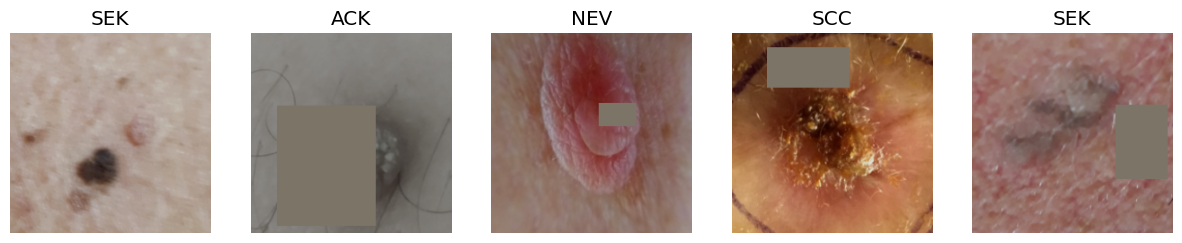

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# Loader temporal con el pipeline de augmentation para visualizar
viz_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)
viz_loader = DataLoader(viz_dataset, batch_size=BATCH_SIZE, shuffle=True)
imgs, labels = next(iter(viz_loader))

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    plt.title(full_train_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

del viz_dataset, viz_loader

**Observaciones:**
- Se aprecian **variaciones en orientación** (flips horizontales/verticales)
- **Random Erasing** visible en imágenes ACK, NEV y SCC (rectángulos grises)
- **Crop + zoom aleatorio** genera diferentes encuadres de la lesión
- Las transformaciones son **realistas** y no distorsionan las características diagnósticas relevantes
Esto confirma que el data augmentation está funcionando correctamente y generará suficiente variabilidad para entrenar modelos robustos con el dataset limitado.

## 5. Pipeline de Entrenamiento y Evaluación

### 5.1 Funciones Auxiliares

Para simplificar los experimentos posteriores y evitar código redundante, se definen funciones modulares que encapsulan todo el flujo de trabajo:

**Predicción y Métricas:**
- `obtener_predicciones()`: Obtiene predicciones, etiquetas y probabilidades de un modelo
- `calcular_metricas()`: Calcula F1, accuracy, precision, recall, kappa
- `mostrar_reporte_completo()`: Genera classification report y matriz de confusión

**Visualización:**
- `plot_training_history()`: Curvas de loss y F1 para un fold individual
- `plot_kfold_history()`: Curvas promediadas de los 5 folds con banda de desviación estándar
- `mostrar_matrices_confusion_folds()`: Grid con las 5 matrices de confusión

**Entrenamiento:**
- `entrenar_modelo()`: Loop de entrenamiento con model saving basado en F1-Macro
  - Guarda el mejor modelo automáticamente
  - Retorna historial de métricas por época

**Pipeline Completo:**
- `lanzar_experimento_kfold()`: Ejecuta todo el flujo de 5-Fold CV
  - Itera sobre los 5 folds
  - Entrena un modelo fresco por fold
  - Calcula class weights para balancear el loss
  - Evalúa en validación de cada fold
  - Genera resumen estadístico (media ± std)
  - Visualiza curvas y matrices de confusión
  - Identifica el mejor fold

**Ventajas del pipeline:**
- **Modularidad**: Cada función tiene una responsabilidad única
- **Reproducibilidad**: Mismo flujo para todos los modelos (ResNet, DenseNet, YOLO)
- **Código limpio**: Los experimentos posteriores serán llamadas simples a `lanzar_experimento_kfold()`
- **Trazabilidad**: Todas las métricas y gráficas se generan automáticamente

Este diseño permite ejecutar experimentos completos con pocas líneas de código, facilitando la comparación entre arquitecturas.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def obtener_predicciones(model, loader, device):
    """Obtiene predicciones, etiquetas reales y probabilidades de un modelo."""
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_probs)


def calcular_metricas(y_true, y_pred):
    """Calcula todas las metricas a partir de etiquetas reales y predichas."""
    return {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
    }


def mostrar_reporte_completo(y_true, y_pred, classes, titulo, mostrar_cm=True):
    """Muestra matriz de confusion, classification report y todas las metricas."""
    metricas = calcular_metricas(y_true, y_pred)

    if mostrar_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes)
        plt.title(f'Matriz de Confusion - {titulo}')
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Prediccion')
        plt.show()

    print(f"\n{'='*70}")
    print(f"REPORTE: {titulo}")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print(f"{'─'*70}")
    print(f"  Accuracy:           {metricas['accuracy']:.4f}")
    print(f"  F1 Macro:           {metricas['f1_macro']:.4f}")
    print(f"  F1 Weighted:        {metricas['f1_weighted']:.4f}")
    print(f"  Precision Macro:    {metricas['precision_macro']:.4f}")
    print(f"  Precision Weighted: {metricas['precision_weighted']:.4f}")
    print(f"  Recall Macro:       {metricas['recall_macro']:.4f}")
    print(f"  Recall Weighted:    {metricas['recall_weighted']:.4f}")
    print(f"  Cohen's Kappa:      {metricas['kappa']:.4f}")
    print(f"{'='*70}")

    return metricas


# ============================================================
# FUNCIONES DE VISUALIZACION
# ============================================================

def plot_training_history(historial, titulo=""):
    """Curvas de entrenamiento de un solo run."""
    epochs = range(1, len(historial['train_loss']) + 1)

    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--', linewidth=2)
    plt.title(f'Loss - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('CrossEntropy Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Val F1 (Macro)', color='green', marker='o', linewidth=2)
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label=f'Mejor: {max(historial["val_f1"]):.4f}')
    plt.title(f'F1-Score - {titulo}')
    plt.xlabel('Epocas')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_kfold_history(historiales, nombre_exp):
    """Curvas promediadas de K folds con banda de desviacion estandar."""
    max_epochs = max(len(h['train_loss']) for h in historiales)

    def pad(lst, length):
        return lst + [lst[-1]] * (length - len(lst))

    train_losses = np.array([pad(h['train_loss'], max_epochs) for h in historiales])
    val_losses = np.array([pad(h['val_loss'], max_epochs) for h in historiales])
    val_f1s = np.array([pad(h['val_f1'], max_epochs) for h in historiales])

    epochs = range(1, max_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Loss
    ax = axes[0]
    mean_tl, std_tl = train_losses.mean(axis=0), train_losses.std(axis=0)
    mean_vl, std_vl = val_losses.mean(axis=0), val_losses.std(axis=0)
    ax.plot(epochs, mean_tl, 'b-', linewidth=2, label='Train Loss (media)')
    ax.fill_between(epochs, mean_tl - std_tl, mean_tl + std_tl, alpha=0.2, color='blue')
    ax.plot(epochs, mean_vl, 'r--', linewidth=2, label='Val Loss (media)')
    ax.fill_between(epochs, mean_vl - std_vl, mean_vl + std_vl, alpha=0.2, color='red')
    ax.set_title(f'Loss Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # F1
    ax = axes[1]
    mean_f1, std_f1 = val_f1s.mean(axis=0), val_f1s.std(axis=0)
    ax.plot(epochs, mean_f1, 'g-', linewidth=2, label='Val F1 Macro (media)')
    ax.fill_between(epochs, mean_f1 - std_f1, mean_f1 + std_f1, alpha=0.2, color='green')
    ax.set_title(f'F1-Score Promedio - {nombre_exp}')
    ax.set_xlabel('Epocas')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def mostrar_matrices_confusion_folds(predicciones_por_fold, classes, nombre_exp):
    """Muestra las 5 matrices de confusión de validación en una sola figura."""
    n_folds = len(predicciones_por_fold)
    fig, axes = plt.subplots(1, n_folds, figsize=(5*n_folds, 5))
    if n_folds == 1:
        axes = [axes]

    for fold_idx, (y_true, y_pred) in enumerate(predicciones_por_fold):
        cm = confusion_matrix(y_true, y_pred)
        metricas = calcular_metricas(y_true, y_pred)

        ax = axes[fold_idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(f'Fold {fold_idx+1}\nF1={metricas["f1_macro"]:.3f} | Acc={metricas["accuracy"]:.3f}')
        ax.set_ylabel('Real' if fold_idx == 0 else '')
        ax.set_xlabel('Predicción')

    plt.suptitle(f'Matrices de Confusión (Validación) - {nombre_exp}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ============================================================
# FUNCION DE ENTRENAMIENTO (un fold)
# ============================================================

def entrenar_modelo(model, train_loader, val_loader, criterion, optimizer, device, epochs=25, nombre_archivo="mejor_modelo.pth"):
    """Entrena un modelo y guarda el mejor segun F1 macro en validacion."""
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'train_f1': []}
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        y_true_train, y_pred_train = [], []
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_f1 = f1_score(y_true_train, y_pred_train, average='macro')

        # Validation
        model.eval()
        val_loss = 0.0
        y_true, y_pred = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_f1 = f1_score(y_true, y_pred, average='macro')

        historial['train_loss'].append(epoch_train_loss)
        historial['train_f1'].append(epoch_train_f1)
        historial['val_loss'].append(epoch_val_loss)
        historial['val_f1'].append(epoch_val_f1)

        marcador = ""
        if epoch_val_f1 > best_f1:
            best_f1 = epoch_val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            marcador = " ** Mejor!"

        print(f"  Ep {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Train F1: {epoch_train_f1:.4f} | Val Loss: {epoch_val_loss:.3f} | Val F1: {epoch_val_f1:.4f}{marcador}")

    print(f"  Mejor F1 Val: {best_f1:.4f}")
    model.load_state_dict(best_model_wts)
    return model, historial


# ============================================================
# PIPELINE 5-FOLD CV (SIN EVALUACION EN TEST)
# ============================================================

def lanzar_experimento_kfold(crear_modelo_fn, nombre_exp, device, epochs=25):
    """
    Ejecuta el pipeline de 5-Fold Cross-Validation SIN evaluar en TEST.
    La evaluación en test se hace al final del notebook.

    Args:
        crear_modelo_fn: funcion(num_classes, device) -> (model, optimizer)
        nombre_exp: nombre del experimento
        device: torch device
        epochs: epocas por fold

    Usa variables globales: full_train_dataset, targets, skf,
        train_pipeline, val_test_pipeline, BATCH_SIZE, SubsetConTransform

    Returns:
        dict con metricas, historiales, modelos y predicciones de validación
    """
    print(f"\n{'='*60}")
    print(f"EXPERIMENTO 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    num_classes = len(full_train_dataset.classes)
    classes = full_train_dataset.classes

    metricas_folds = []
    historiales = []
    modelos_state_dicts = []
    predicciones_val_por_fold = []  # (y_true, y_pred) por fold
    probs_val_por_fold = []  # probabilidades para ensemble

    # Guardar indices de validación para reconstruir todas las predicciones
    indices_val_todos = []
    y_true_val_todos = []
    y_pred_val_todos = []
    y_probs_val_todos = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
        print(f"\n{'─'*50}")
        print(f"FOLD {fold+1}/{skf.n_splits} | Train: {len(train_idx)} | Val: {len(val_idx)}")
        print(f"{'─'*50}")

        # --- DataLoaders del fold ---
        fold_train = SubsetConTransform(full_train_dataset, train_idx, train_pipeline)
        fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)

        fold_train_loader = DataLoader(
            fold_train, batch_size=BATCH_SIZE, shuffle=True,
            num_workers=8, pin_memory=True
        )
        fold_val_loader = DataLoader(
            fold_val, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=4, pin_memory=True
        )

        # --- Pesos de clase para este fold ---
        fold_targets = [targets[i] for i in train_idx]
        class_counts = np.bincount(fold_targets, minlength=num_classes).astype(float)
        weights = 1.0 / class_counts
        weights = weights / weights.sum() * num_classes
        class_weights = torch.FloatTensor(weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        # --- Modelo y optimizador frescos ---
        model, optimizer = crear_modelo_fn(num_classes, device)

        # --- Entrenar ---
        model, historial = entrenar_modelo(
            model, fold_train_loader, fold_val_loader,
            criterion, optimizer, device, epochs,
            nombre_archivo=f"{nombre_exp}_fold{fold+1}.pth"
        )

        # --- Metricas del fold en validacion ---
        y_true_val, y_pred_val, y_probs_val = obtener_predicciones(model, fold_val_loader, device)
        fold_metricas = calcular_metricas(y_true_val, y_pred_val)

        print(f"  >> Fold {fold+1} Val: F1={fold_metricas['f1_macro']:.4f} | "
              f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

        metricas_folds.append(fold_metricas)
        historiales.append(historial)
        modelos_state_dicts.append(copy.deepcopy(model.state_dict()))
        predicciones_val_por_fold.append((y_true_val, y_pred_val))

        # Acumular para evaluación global de validación
        y_true_val_todos.extend(y_true_val)
        y_pred_val_todos.extend(y_pred_val)
        y_probs_val_todos.extend(y_probs_val)
        indices_val_todos.extend(val_idx)

    # ============================================================
    # RESUMEN CROSS-VALIDATION
    # ============================================================
    print(f"\n{'='*60}")
    print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
    print(f"{'='*60}")

    metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                    'precision_macro', 'precision_weighted',
                    'recall_macro', 'recall_weighted', 'kappa']

    tabla = {}
    for metric in metric_names:
        valores = [m[metric] for m in metricas_folds]
        tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

    cols = [f"Fold {i+1}" for i in range(skf.n_splits)] + ["Media", "Std"]
    df_resumen = pd.DataFrame(tabla, index=cols).T
    print(df_resumen.to_string())

    # --- Curvas promediadas ---
    print(f"\nCurvas de entrenamiento promediadas:")
    plot_kfold_history(historiales, nombre_exp)

    # --- Curvas individuales por fold ---
    for i, h in enumerate(historiales):
        plot_training_history(h, titulo=f"{nombre_exp} - Fold {i+1}")

    # ============================================================
    # MATRICES DE CONFUSION POR FOLD (VALIDACION)
    # ============================================================
    print(f"\n{'='*60}")
    print(f"MATRICES DE CONFUSION POR FOLD (VALIDACION) - {nombre_exp}")
    print(f"{'='*60}")

    mostrar_matrices_confusion_folds(predicciones_val_por_fold, classes, nombre_exp)

    # ============================================================
    # EVALUACION GLOBAL EN VALIDACION (todos los folds combinados)
    # ============================================================
    print(f"\n{'='*60}")
    print(f"EVALUACION GLOBAL VALIDACION (todos los folds) - {nombre_exp}")
    print(f"{'='*60}")

    y_true_val_todos = np.array(y_true_val_todos)
    y_pred_val_todos = np.array(y_pred_val_todos)

    metricas_val_global = mostrar_reporte_completo(
        y_true_val_todos, y_pred_val_todos, classes,
        f"VALIDACION GLOBAL - {nombre_exp}"
    )

    # ============================================================
    # ENSEMBLE DE 5 FOLDS EVALUADO EN VALIDACION
    # ============================================================
    print(f"\n{'='*60}")
    print(f"ENSEMBLE {skf.n_splits} FOLDS - VALIDACION - {nombre_exp}")
    print(f"{'='*60}")
    print("Nota: Cada muestra de validación solo fue vista por 1 modelo (su fold).")
    print("Para ensemble en validación, usamos las probabilidades del modelo que predijo cada muestra.")

    # Las predicciones ya son del modelo correcto para cada muestra
    # El ensemble en validación es equivalente a las predicciones individuales
    # porque cada muestra solo tiene predicción de un modelo

    y_probs_val_todos = np.array(y_probs_val_todos)
    y_pred_ensemble_val = np.argmax(y_probs_val_todos, axis=1)

    # Verificar que son iguales (deben serlo)
    print(f"Verificación: predicciones ensemble == predicciones individuales: {np.array_equal(y_pred_ensemble_val, y_pred_val_todos)}")

    # ============================================================
    # MEJOR FOLD
    # ============================================================
    f1_scores = [m['f1_macro'] for m in metricas_folds]
    best_fold = int(np.argmax(f1_scores))

    print(f"\n{'='*60}")
    print(f"MEJOR FOLD: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")
    print(f"{'='*60}")

    return {
        'metricas_folds': metricas_folds,
        'historiales': historiales,
        'modelos_state_dicts': modelos_state_dicts,
        'best_fold': best_fold,
        'df_resumen': df_resumen,
        'predicciones_val_por_fold': predicciones_val_por_fold,
        'metricas_val_global': metricas_val_global,
        'classes': classes,
        'num_classes': num_classes,
    }


print("Funciones cargadas (SIN evaluación en test).")


Funciones cargadas (SIN evaluación en test).


## 6. Experimentos con Transfer Learning

### 6.1 ResNet18

**ResNet18** es una arquitectura residual de 18 capas que utiliza conexiones skip para facilitar el flujo de gradientes. Se usa transfer learning desde ImageNet con congelación parcial.

#### Configuración

**Transfer Learning:**
- Se cargan pesos preentrenados de ImageNet (`ResNet18_Weights.DEFAULT`)
- Se congelan todas las capas **excepto `layer4`** (último bloque residual)
- El clasificador FC se reemplaza por uno nuevo con dropout

**Arquitectura del clasificador:**
```python
nn.Sequential(
    nn.Dropout(0.3),           # Regularización
    nn.Linear(512, num_classes) # 6 clases
)
```

**Hiperparámetros Optimizados** (obtenidos por Optuna):
- `lr_backbone`: 0.000131 (learning rate para `layer4`)
- `lr_head`: 0.000437 (learning rate para clasificador)
- `weight_decay`: 0.002365 (regularización L2)
- `dropout`: 0.3
- `batch_size`: 16
- `optimizer`: AdamW con learning rates diferenciados

**Justificación:**
- El clasificador tiene mayor LR (0.000437) que el backbone (0.000131) porque debe aprender desde cero
- AdamW combina Adam con weight decay desacoplado, mejorando la generalización
- Dropout de 0.3 previene overfitting en el dataset pequeño


Usando device: cuda

EXPERIMENTO 5-FOLD CV: ResNet18_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/15 | Train Loss: 1.691 | Train F1: 0.2656 | Val Loss: 1.335 | Val F1: 0.4368 ** Mejor!
  Ep 2/15 | Train Loss: 1.294 | Train F1: 0.4807 | Val Loss: 1.238 | Val F1: 0.5566 ** Mejor!
  Ep 3/15 | Train Loss: 1.190 | Train F1: 0.5017 | Val Loss: 1.288 | Val F1: 0.4717
  Ep 4/15 | Train Loss: 1.101 | Train F1: 0.5355 | Val Loss: 1.202 | Val F1: 0.5658 ** Mejor!
  Ep 5/15 | Train Loss: 0.971 | Train F1: 0.5925 | Val Loss: 1.266 | Val F1: 0.5589
  Ep 6/15 | Train Loss: 0.994 | Train F1: 0.5956 | Val Loss: 1.185 | Val F1: 0.5923 ** Mejor!
  Ep 7/15 | Train Loss: 0.902 | Train F1: 0.6253 | Val Loss: 1.201 | Val F1: 0.5375
  Ep 8/15 | Train Loss: 0.805 | Train F1: 0.6928 | Val Loss: 1.181 | Val F1: 0.5371
  Ep 9/15 | Train Loss: 0.707 | Train F1: 0.7233 | Val Loss: 1.171 | Val F1: 0.5352
  Ep 10/1

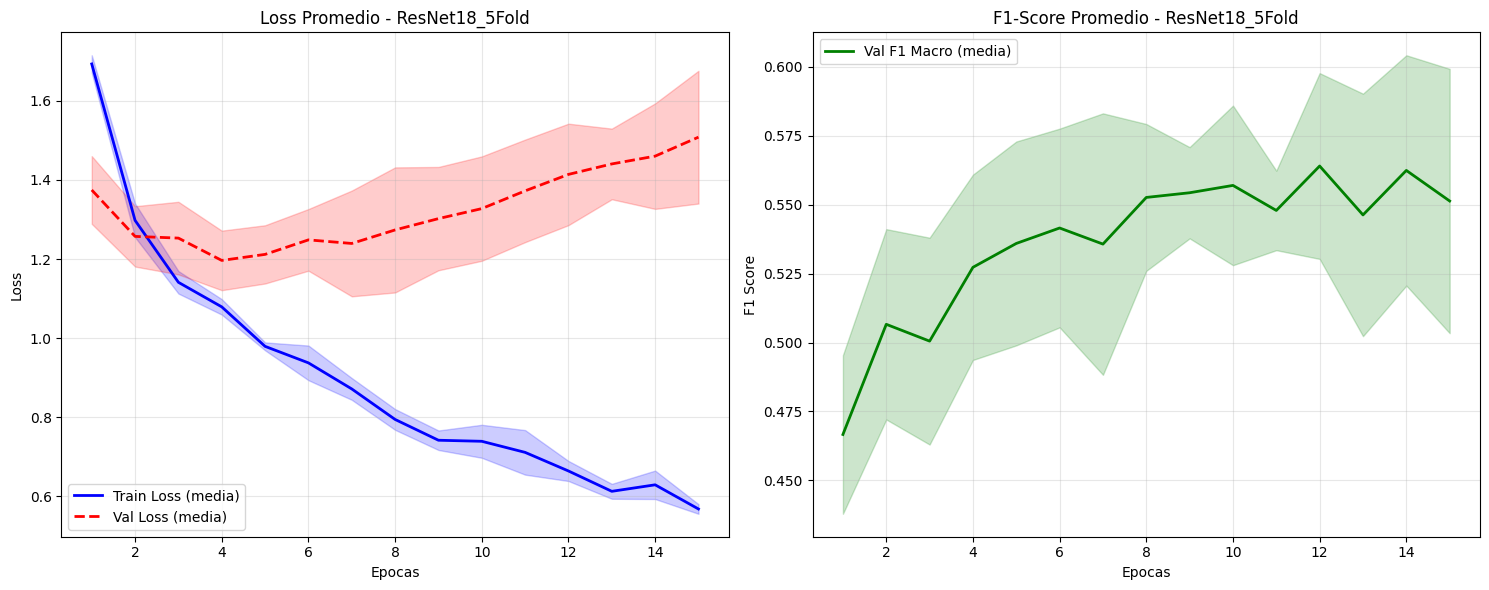

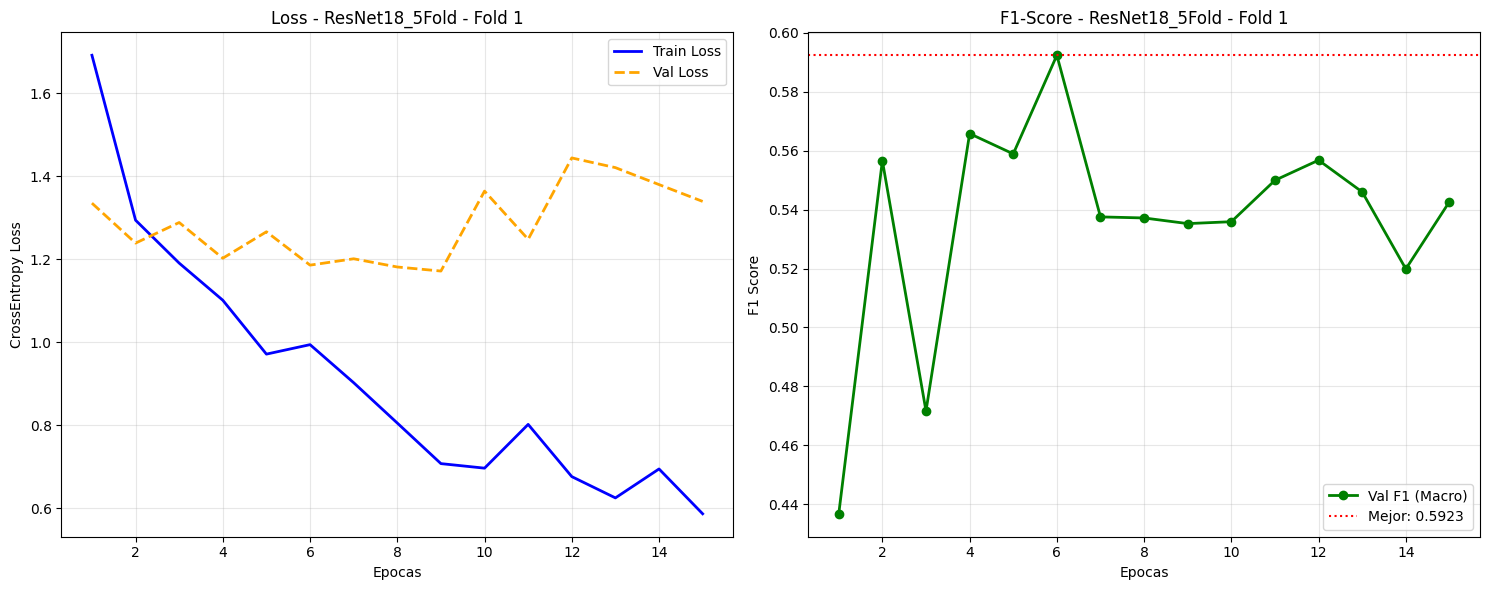

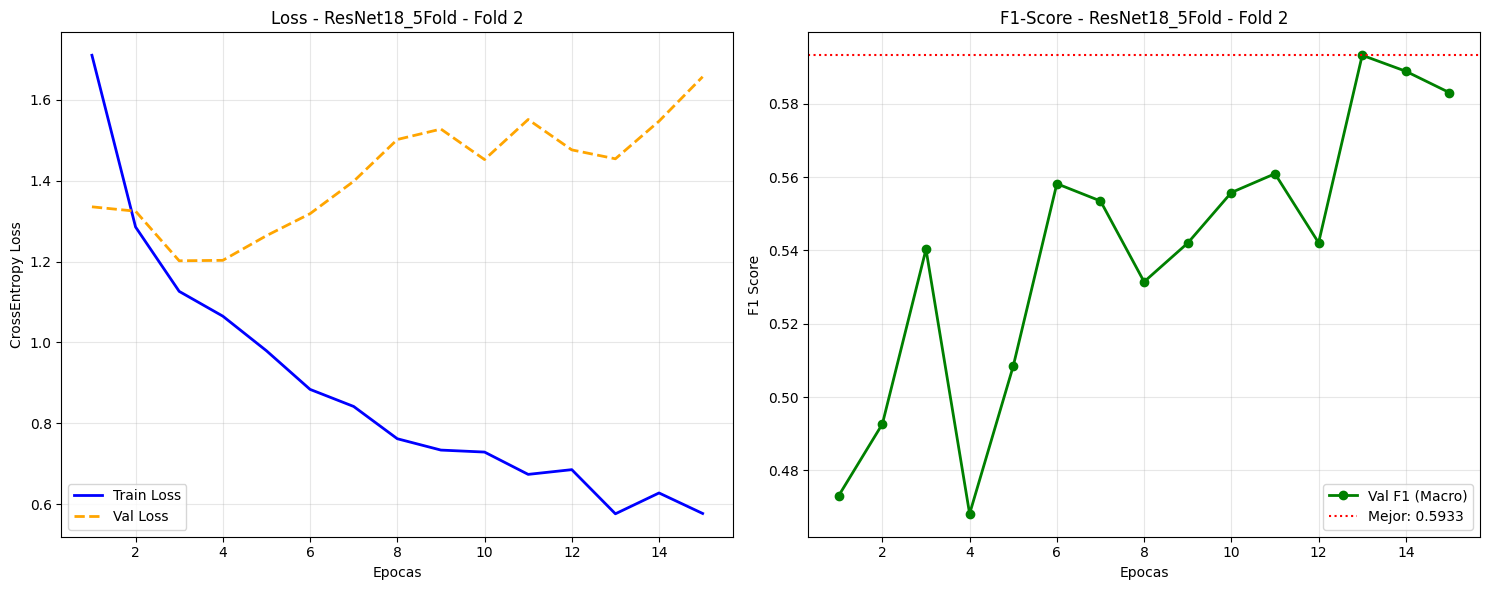

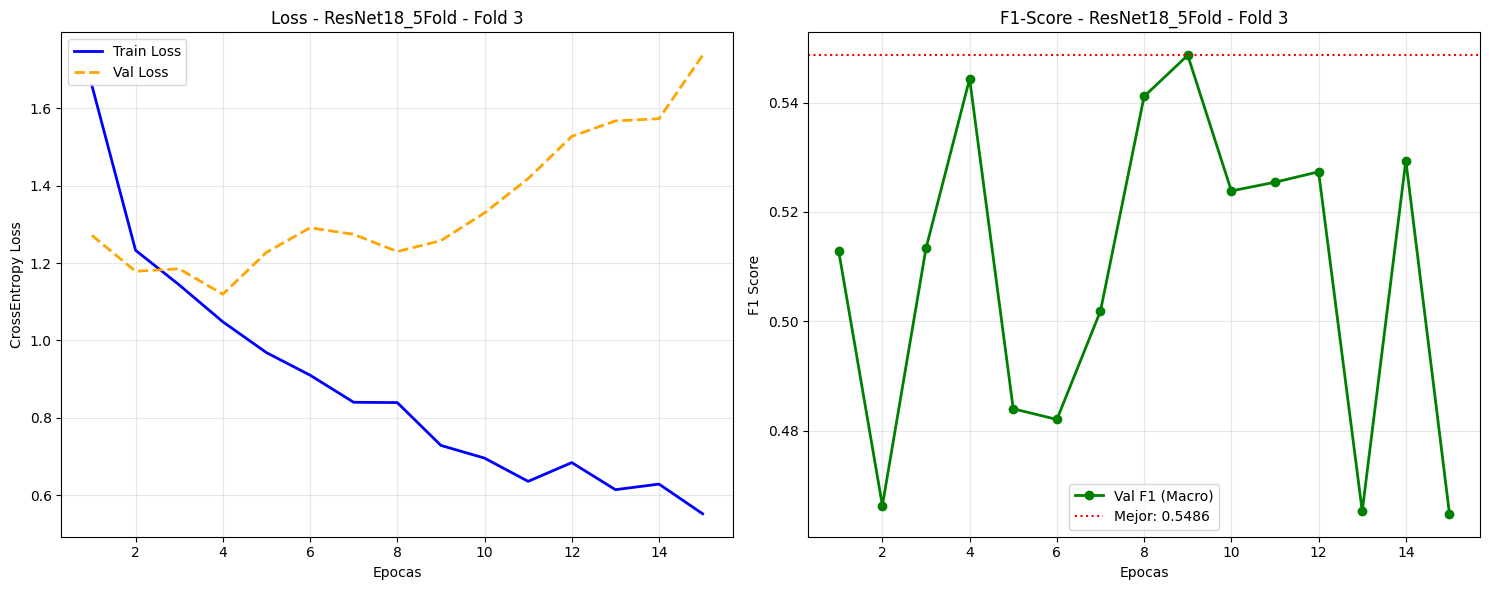

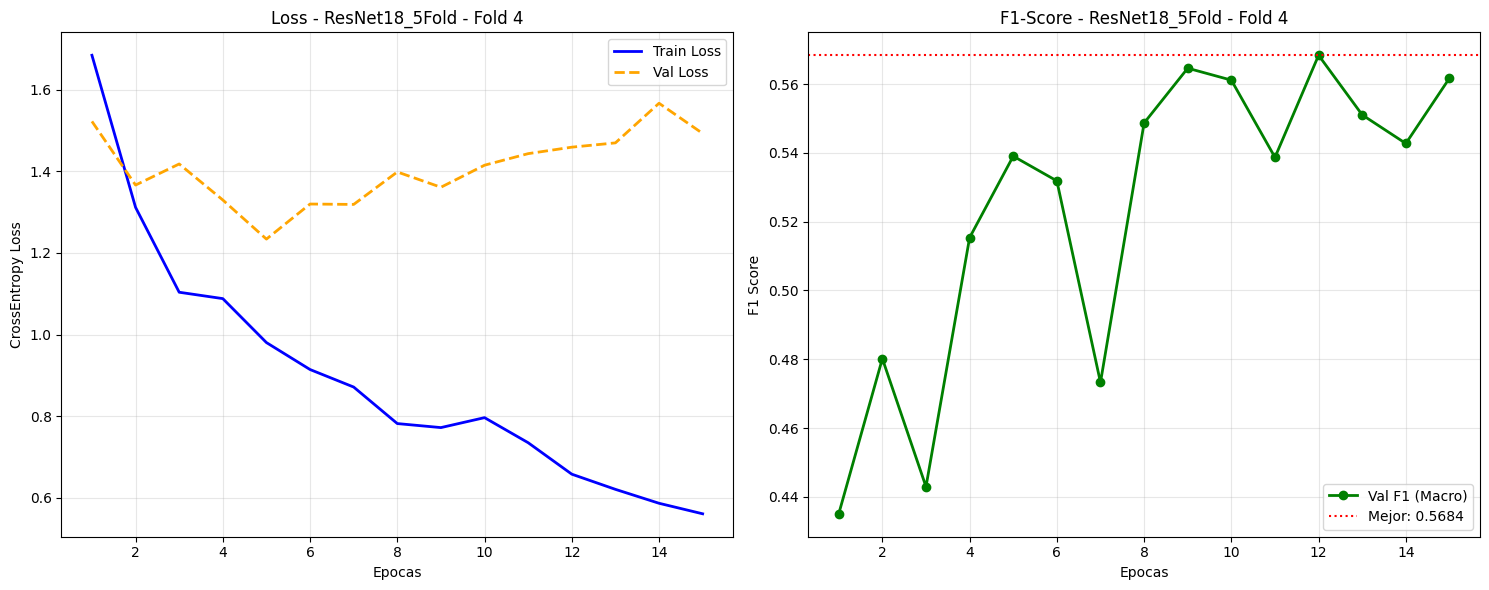

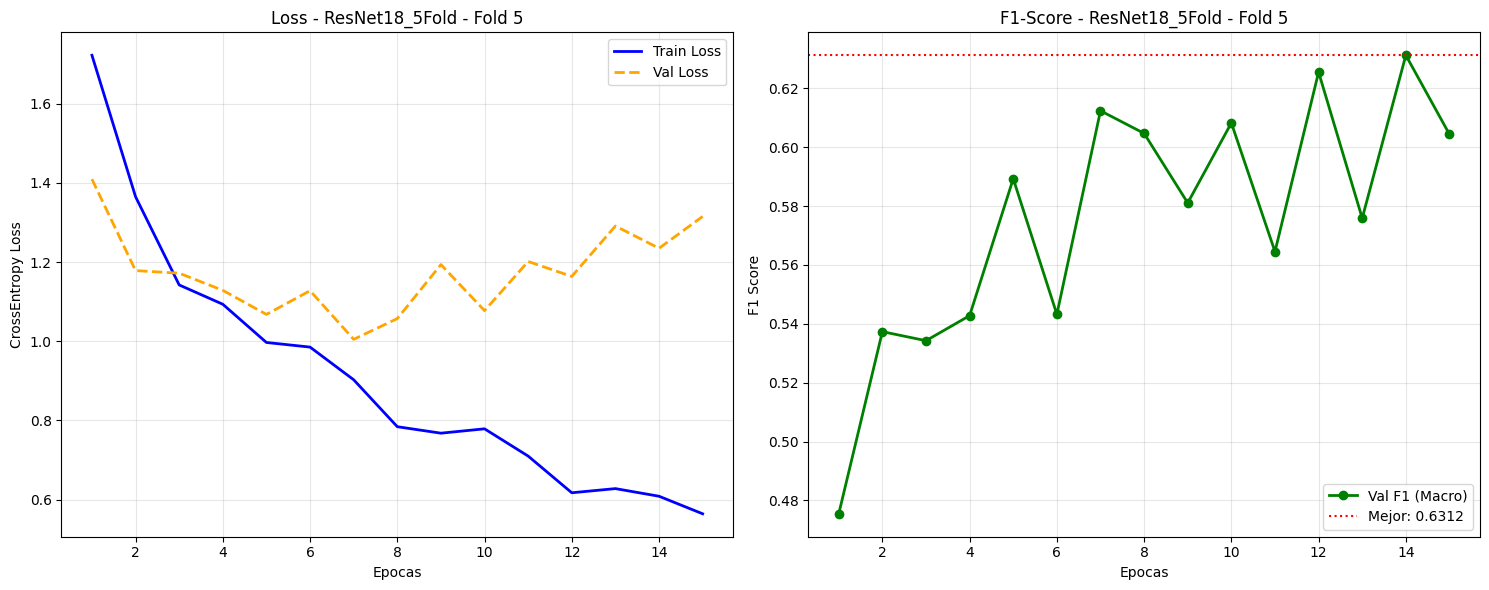


MATRICES DE CONFUSION POR FOLD (VALIDACION) - ResNet18_5Fold


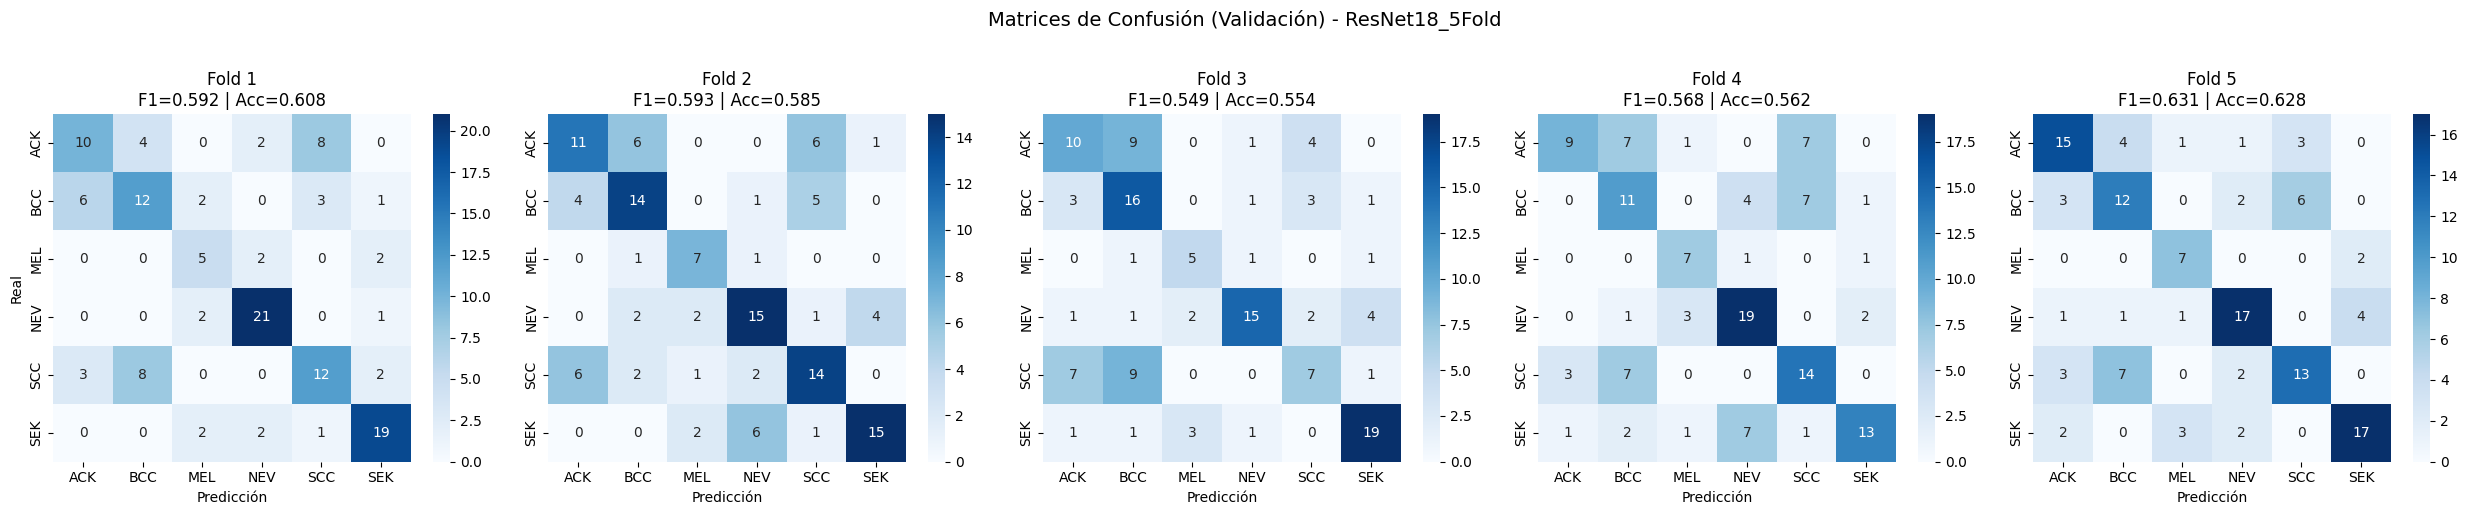


EVALUACION GLOBAL VALIDACION (todos los folds) - ResNet18_5Fold


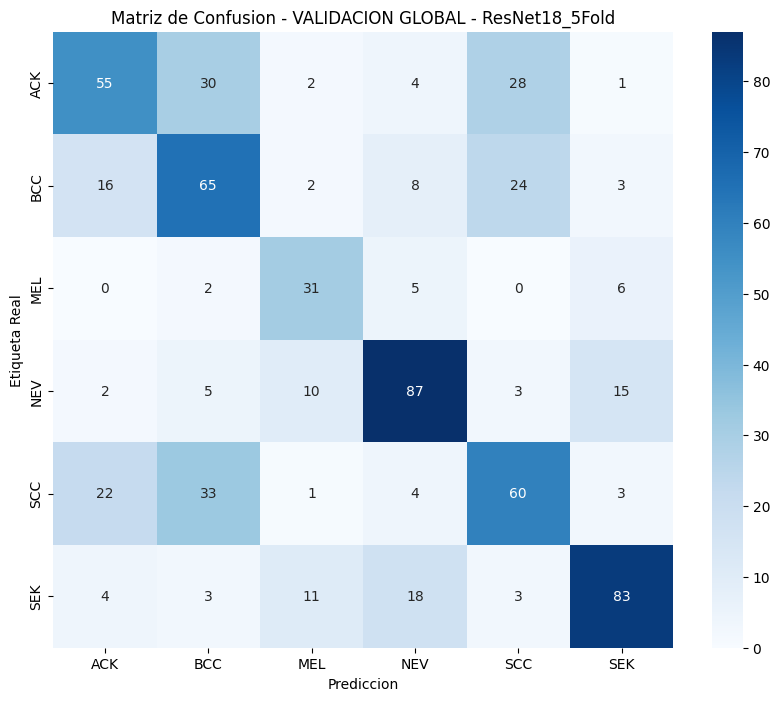


REPORTE: VALIDACION GLOBAL - ResNet18_5Fold
              precision    recall  f1-score   support

         ACK       0.56      0.46      0.50       120
         BCC       0.47      0.55      0.51       118
         MEL       0.54      0.70      0.61        44
         NEV       0.69      0.71      0.70       122
         SCC       0.51      0.49      0.50       123
         SEK       0.75      0.68      0.71       122

    accuracy                           0.59       649
   macro avg       0.59      0.60      0.59       649
weighted avg       0.59      0.59      0.59       649

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5871
  F1 Macro:           0.5893
  F1 Weighted:        0.5870
  Precision Macro:    0.5862
  Precision Weighted: 0.5920
  Recall Macro:       0.5992
  Recall Weighted:    0.5871
  Cohen's Kappa:      0.4989

ENSEMBLE 5 FOLDS - VALIDACION - ResNet18_5Fold
Nota: Cada muestra de validación solo fue vista por 1 modelo 

In [7]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_resnet18(num_classes, device):

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, num_classes)
        )
    model = model.to(device)

    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 0.000131},
        {'params': model.fc.parameters(), 'lr': 0.000437}
    ], weight_decay=0.02365)

    return model, optimizer


resultados_resnet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_resnet18,
    nombre_exp="ResNet18_5Fold",
    device=device,
    epochs=15
)


#### Resultados - ResNet18

**Métricas de Validación (5-Fold CV):**
- **F1-Macro (promedio de folds)**: 0.5868 ± 0.0277
- **F1-Macro (validación agregada)**: 0.5893
- **Accuracy**: 0.5871 ± 0.0278
- **Cohen's Kappa**: 0.4989 ± 0.0340
- **Mejor Fold Individual**: Fold 5 (F1=0.6312)

**Diferencia entre métricas:**
- **0.5868**: Promedio aritmético de los F1 de cada fold (0.5923, 0.5933, 0.5486, 0.5684, 0.6312)
- **0.5893**: F1-Macro calculado directamente sobre las 649 predicciones agregadas de validación
- La diferencia es pequeña pero existe porque promediar F1s no es exactamente igual que calcular F1 sobre datos agregados (especialmente con clases desbalanceadas)

**Observaciones clave:**

1. **Smart Saving**: El modelo entrena las 15 épocas completas, pero se guarda automáticamente el checkpoint con mejor F1-Macro en validación. Esto permite explorar todo el espacio de entrenamiento sin perder el mejor modelo.

2. **Divergencia Loss vs F1**: Se observa en todos los folds que el val loss aumenta progresivamente (~1.0 → 1.5) mientras que el val F1 se mantiene o mejora. Esto ocurre porque:
   - **CrossEntropyLoss** penaliza la confianza de las probabilidades predichas
   - **F1-Score** solo evalúa si la clase con mayor probabilidad es correcta o no
   
   El modelo aprende a clasificar mejor (más aciertos) pero con menor confianza en las probabilidades. Por eso es válido seleccionar épocas tardías donde el F1 es máximo aunque el loss sea alto.

3. **Métrica F1-Macro**: Promedio sin ponderar del F1 de cada clase. Se prioriza sobre accuracy para no ignorar MEL (clase minoritaria crítica).

4. **Matriz de Confusión Agregada**: Combina las predicciones de validación de los 5 folds (649 muestras totales). Cada muestra aparece exactamente una vez.

5. **Performance por clase** (validación agregada):
   - ✅ **MEL**: 70% recall (31/44 detectados) - prioridad clínica cumplida
   - ✅ **NEV**: 71% recall, **SEK**: 68% recall - clases mejor identificadas
   - ⚠️ **ACK**: 46% recall, **SCC**: 49% recall - mayor confusión
   - ⚠️ **BCC**: 55% recall - performance intermedio

6. **Confusiones principales**:
   - ACK → SCC (28 casos): Confusión entre lesiones precancerosas
   - SCC → BCC (33 casos), BCC → SCC (24 casos): Difícil distinguir carcinomas

**Conclusión**: ResNet18 alcanza **58.68% F1-Macro** con buena detección de MEL (70% recall). El smart saving basado en F1 permite seleccionar épocas donde la capacidad de clasificación es máxima, independientemente del valor del loss.

**Modelo seleccionado**: **Fold 5** (F1=0.6312, `ResNet18_5Fold_fold5.pth`) se usará para la evaluación final en test.

### 6.2 DenseNet121

**DenseNet121** es una arquitectura con conexiones densas donde cada capa recibe entrada de todas las capas anteriores, mejorando la reutilización de features y reduciendo la degradación del gradiente. Se usa transfer learning con congelación parcial.

#### Configuración

**Transfer Learning:**
- Se cargan pesos preentrenados de ImageNet (`DenseNet121_Weights.DEFAULT`)
- Se congelan los primeros bloques densos (`denseblock1`, `denseblock2`, `denseblock3`)
- Se entrenan **`denseblock4` + `norm5`** (últimas capas densas y normalización final)
- El clasificador FC se reemplaza por uno nuevo con dropout

**Arquitectura del clasificador:**
```python
nn.Sequential(
    nn.Dropout(0.4),           # Regularización más agresiva que ResNet
    nn.Linear(1024, num_classes) # 6 clases
)
```

**Hiperparámetros Optimizados** (obtenidos por Optuna):
- `lr_backbone`: 0.000960 (para `denseblock4` + `norm5`)
- `lr_head`: 0.000218 (para clasificador, más bajo que ResNet)
- `weight_decay`: 0.000089 (regularización L2 más baja que ResNet)
- `dropout`: 0.4 (más agresivo que ResNet: 0.3)
- `batch_size`: 16
- `optimizer`: AdamW con learning rates diferenciados

**Justificación:**
- Dropout más alto (0.4) compensa la mayor capacidad de DenseNet por conexiones densas
- Weight decay más bajo (0.000089) porque dropout ya regulariza fuertemente
- LR head más bajo (0.000218 vs 0.000437 de ResNet) para convergencia más estable

Usando device: cuda

EXPERIMENTO 5-FOLD CV: DenseNet121_5Fold

──────────────────────────────────────────────────
FOLD 1/5 | Train: 519 | Val: 130
──────────────────────────────────────────────────
  Ep 1/15 | Train Loss: 1.583 | Train F1: 0.3063 | Val Loss: 1.258 | Val F1: 0.5010 ** Mejor!
  Ep 2/15 | Train Loss: 1.217 | Train F1: 0.5234 | Val Loss: 1.217 | Val F1: 0.5123 ** Mejor!
  Ep 3/15 | Train Loss: 1.060 | Train F1: 0.5644 | Val Loss: 1.112 | Val F1: 0.5035
  Ep 4/15 | Train Loss: 0.972 | Train F1: 0.6351 | Val Loss: 1.157 | Val F1: 0.5316 ** Mejor!
  Ep 5/15 | Train Loss: 0.899 | Train F1: 0.6331 | Val Loss: 1.117 | Val F1: 0.5951 ** Mejor!
  Ep 6/15 | Train Loss: 0.824 | Train F1: 0.6534 | Val Loss: 1.078 | Val F1: 0.6087 ** Mejor!
  Ep 7/15 | Train Loss: 0.787 | Train F1: 0.7045 | Val Loss: 1.157 | Val F1: 0.5312
  Ep 8/15 | Train Loss: 0.758 | Train F1: 0.6935 | Val Loss: 1.146 | Val F1: 0.6290 ** Mejor!
  Ep 9/15 | Train Loss: 0.792 | Train F1: 0.6979 | Val Loss: 1.137 | V

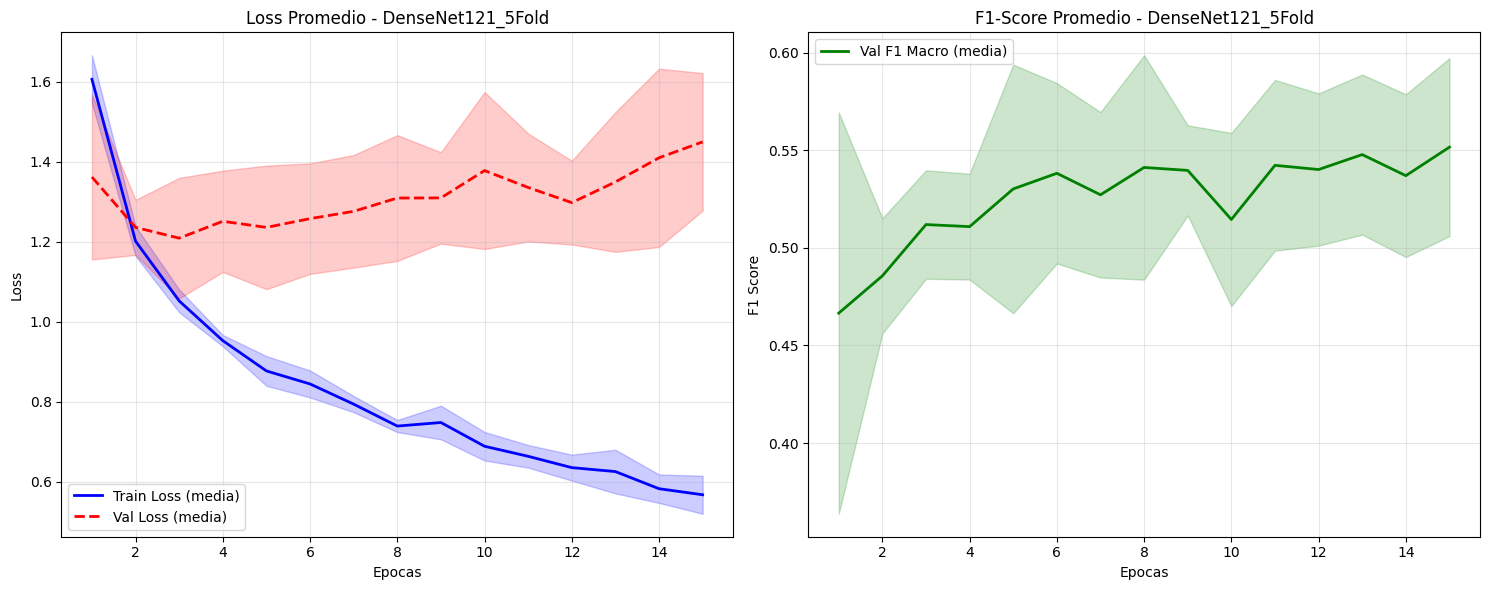

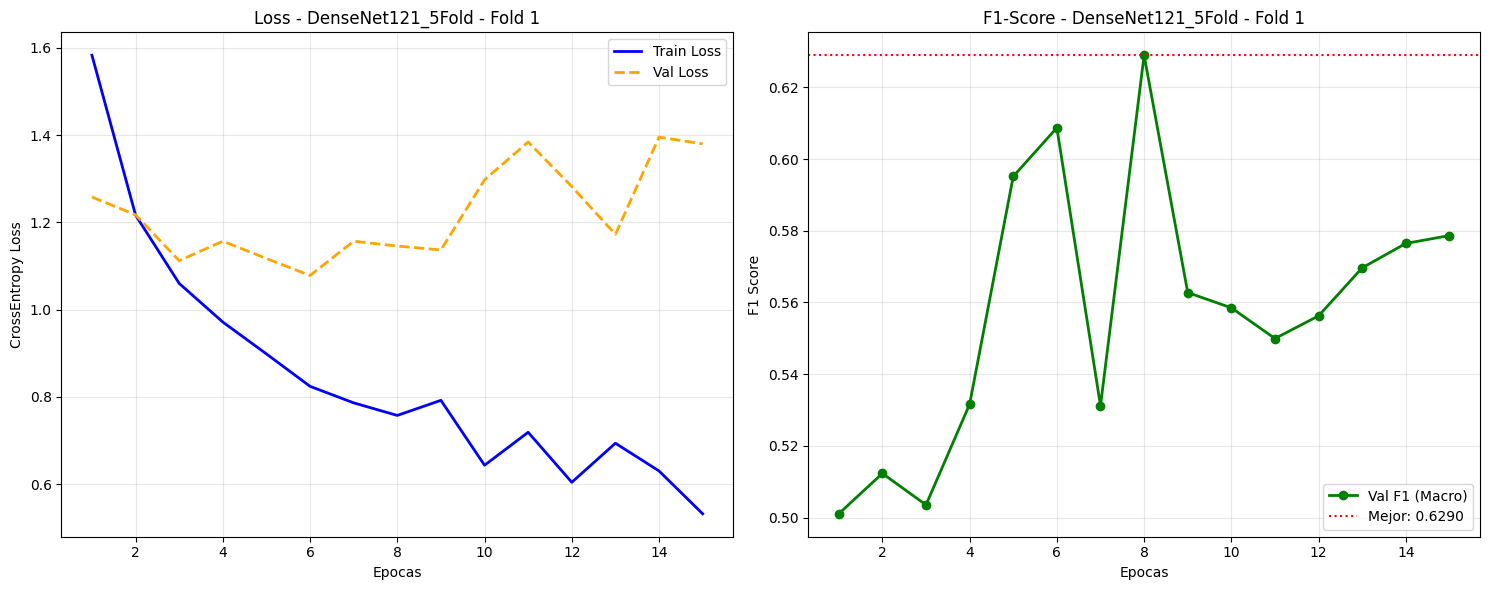

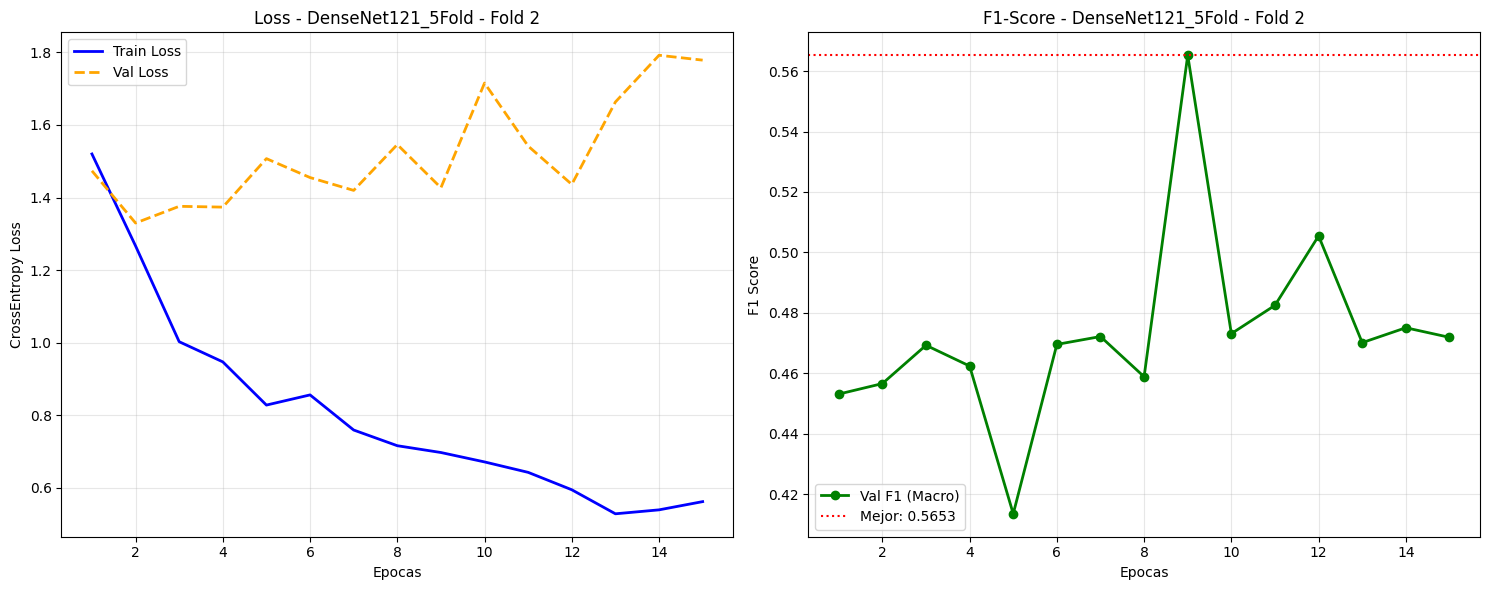

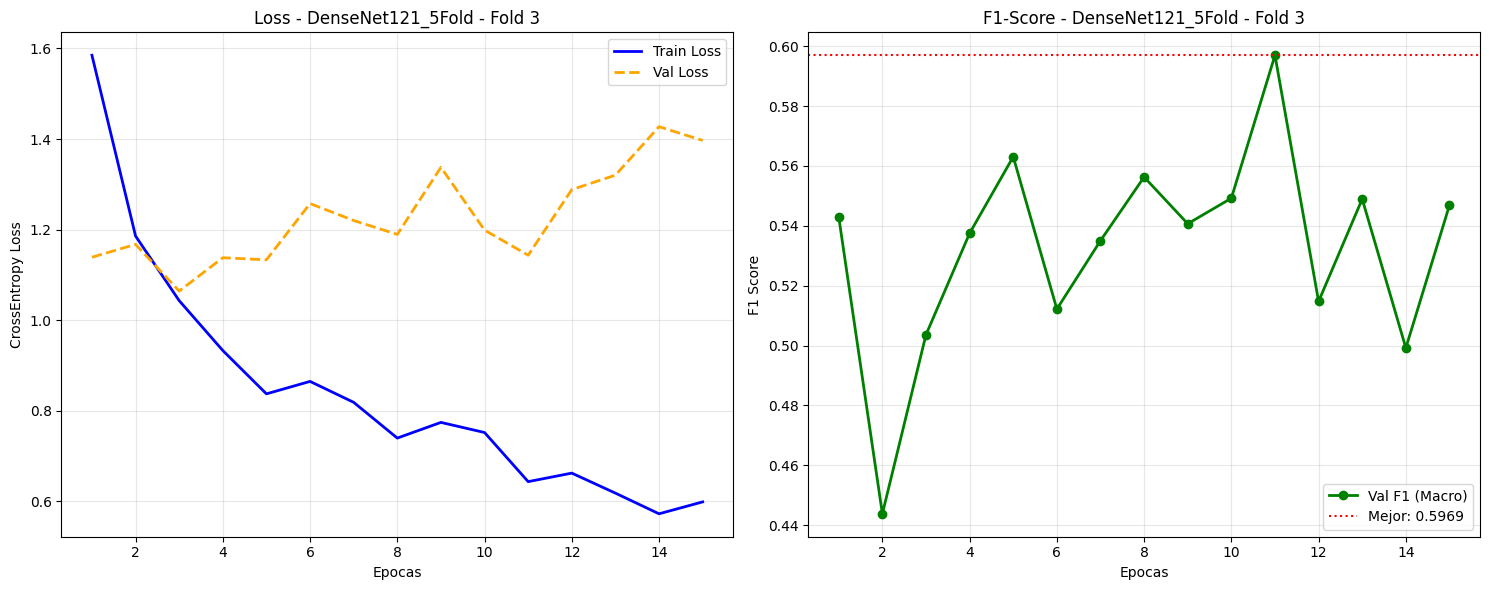

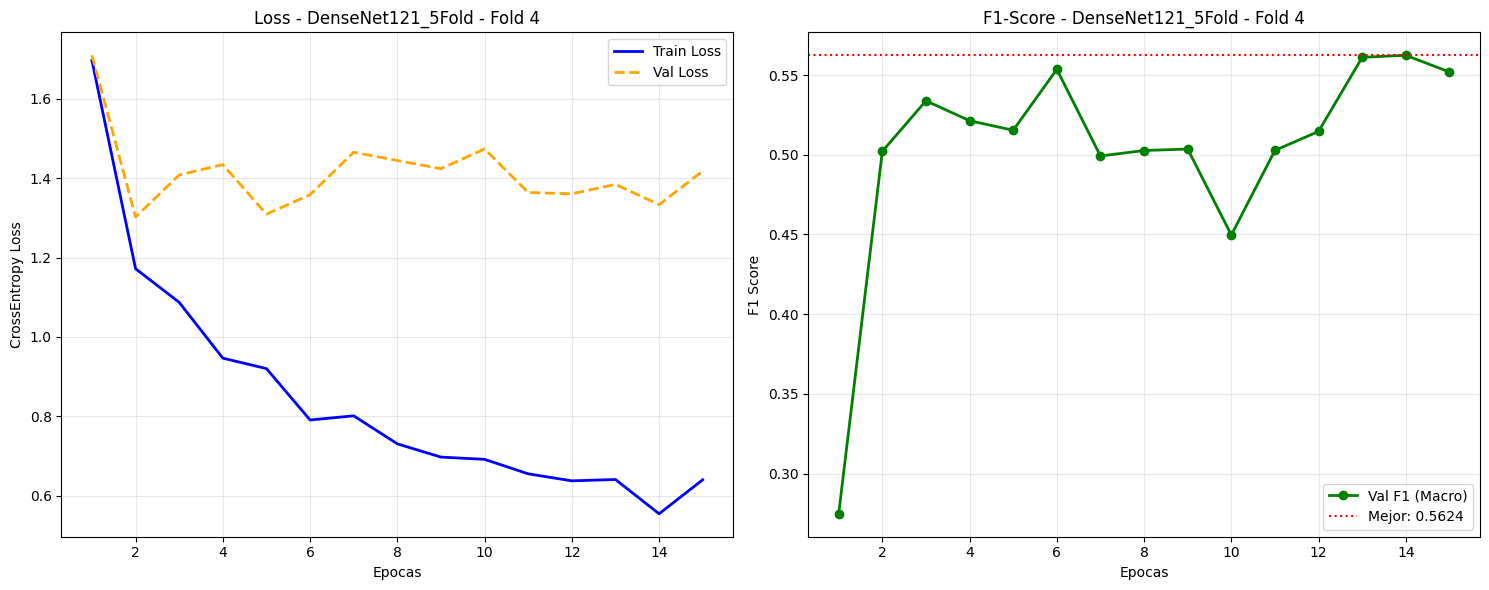

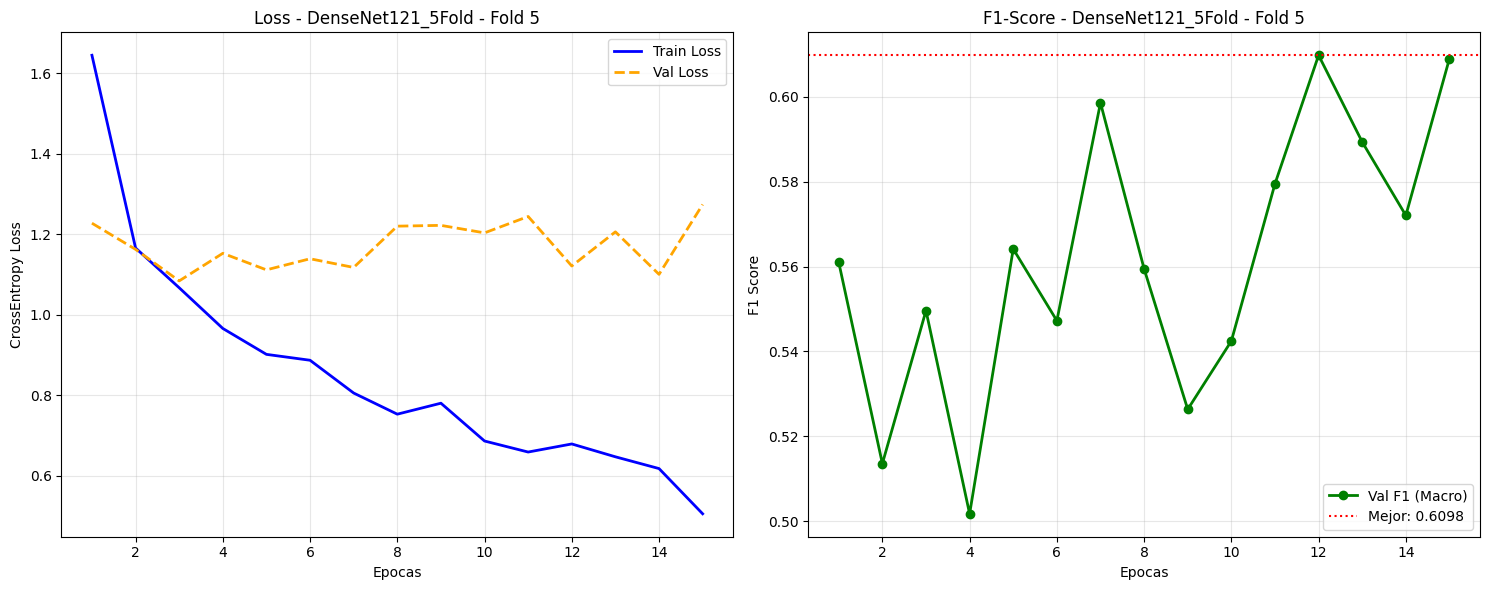


MATRICES DE CONFUSION POR FOLD (VALIDACION) - DenseNet121_5Fold


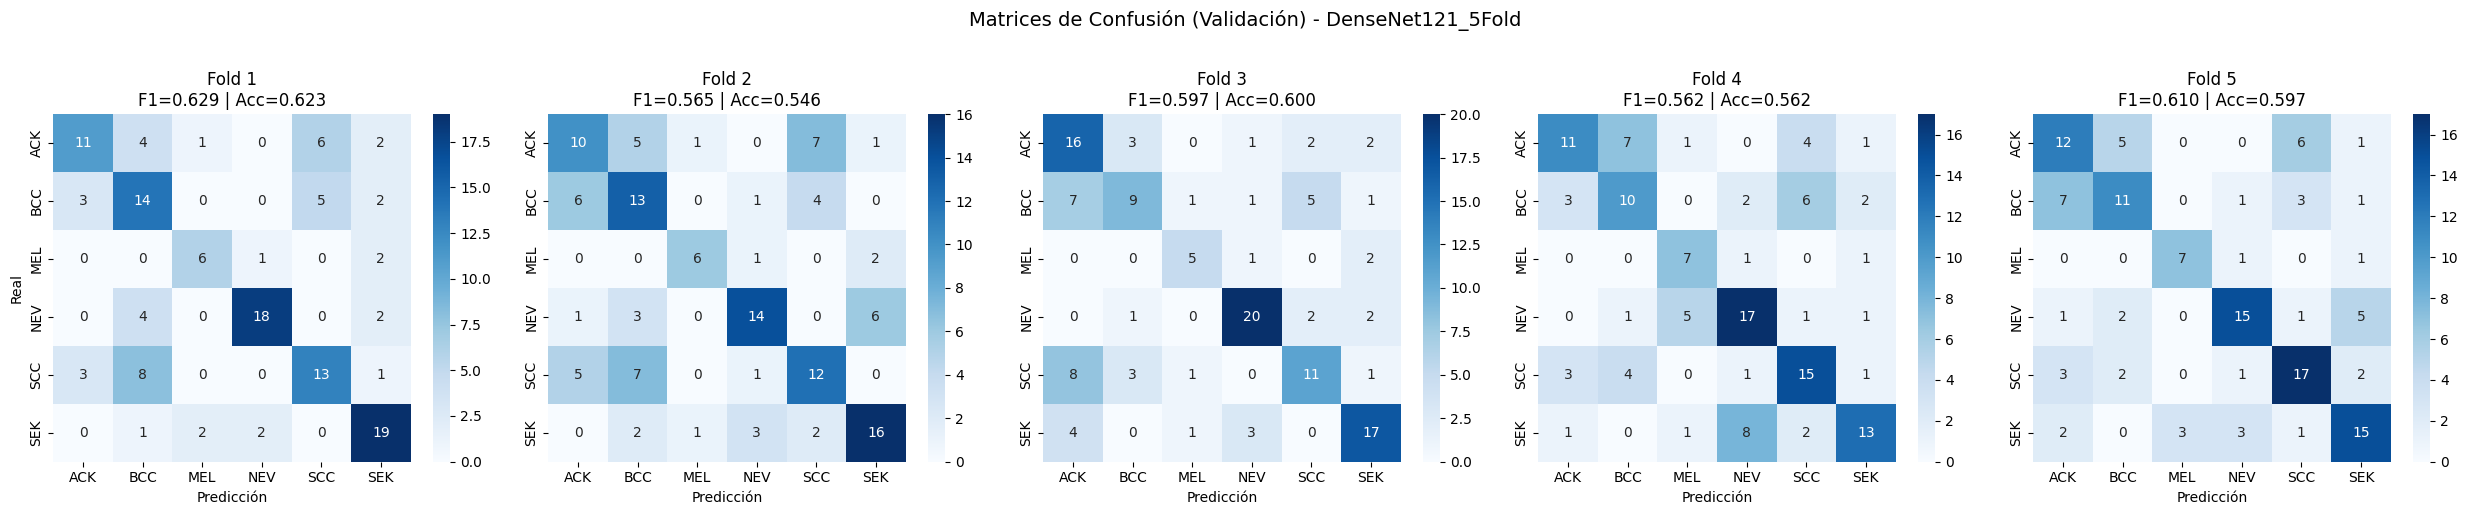


EVALUACION GLOBAL VALIDACION (todos los folds) - DenseNet121_5Fold


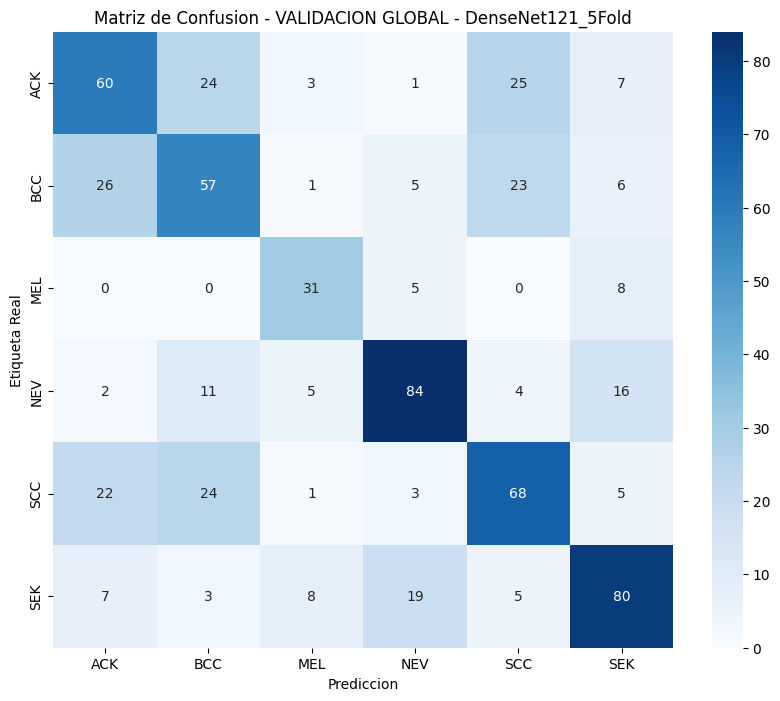


REPORTE: VALIDACION GLOBAL - DenseNet121_5Fold
              precision    recall  f1-score   support

         ACK       0.51      0.50      0.51       120
         BCC       0.48      0.48      0.48       118
         MEL       0.63      0.70      0.67        44
         NEV       0.72      0.69      0.70       122
         SCC       0.54      0.55      0.55       123
         SEK       0.66      0.66      0.66       122

    accuracy                           0.59       649
   macro avg       0.59      0.60      0.59       649
weighted avg       0.59      0.59      0.59       649

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5855
  F1 Macro:           0.5935
  F1 Weighted:        0.5856
  Precision Macro:    0.5904
  Precision Weighted: 0.5861
  Recall Macro:       0.5975
  Recall Weighted:    0.5855
  Cohen's Kappa:      0.4961

ENSEMBLE 5 FOLDS - VALIDACION - DenseNet121_5Fold
Nota: Cada muestra de validación solo fue vista por 1 m

In [8]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)


def crear_densenet121(num_classes, device):
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
    for param in model.features.norm5.parameters():
        param.requires_grad = True

    num_ftrs = model.classifier.in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_ftrs, num_classes)
        )

    model = model.to(device)
    optimizer = optim.AdamW([
        {'params': model.features.denseblock4.parameters(), 'lr': 0.000960},
        {'params': model.features.norm5.parameters(), 'lr': 0.000960},
        {'params': model.classifier.parameters(), 'lr': 0.000218}
    ], weight_decay=0.000089)
    return model, optimizer


resultados_densenet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_densenet121,
    nombre_exp="DenseNet121_5Fold",
    device=device,
    epochs=15
)


#### Resultados - DenseNet121

**Métricas de Validación (5-Fold CV):**
- **F1-Macro (promedio de folds)**: 0.5927 ± 0.0257
- **F1-Macro (validación agregada)**: 0.5935
- **Accuracy**: 0.5855 ± 0.0278
- **Cohen's Kappa**: 0.4960 ± 0.0335
- **Mejor Fold Individual**: Fold 1 (F1=0.6290)

**Diferencia entre métricas:**
- **0.5927**: Promedio aritmético de los F1 de cada fold
- **0.5935**: F1-Macro sobre las 649 predicciones agregadas de validación

**Observaciones clave:**

1. **Smart Saving**: Modelo guardado automáticamente en la época con mejor F1-Macro por fold.

2. **Divergencia Loss vs F1**: Similar a ResNet, el val loss aumenta progresivamente mientras el F1 se mantiene o mejora. El modelo aprende a clasificar mejor pero con menor confianza en probabilidades.

3. **Performance por clase** (validación agregada):
   - ✅ **MEL**: 70% recall (31/44) - igual que ResNet, prioridad clínica cumplida
   - ✅ **NEV**: 69% recall, **SEK**: 66% recall
   - ✅ **SCC**: 55% recall - mejora vs ResNet (49%)
   - ⚠️ **BCC**: 48% recall - peor que ResNet (55%)
   - ⚠️ **ACK**: 50% recall - mejora vs ResNet (46%)

4. **Confusiones principales**:
   - ACK → SCC (25 casos) - reducido vs ResNet (28)
   - SCC → BCC (24 casos), BCC → SCC (23 casos) - similares confusiones bidireccionales
   - NEV → SEK (16 casos) - confusión entre lesiones benignas

5. **Variabilidad entre folds**: Muy baja (std=0.026), indicando estabilidad del modelo.

**Comparación con ResNet18:**
- DenseNet: **F1=0.5935** vs ResNet: **F1=0.5893** (+0.7% mejora)
- Ambos logran **70% recall en MEL**
- DenseNet mejora en SCC y ACK, pero empeora ligeramente en BCC

**Conclusión**: DenseNet121 alcanza **59.27% F1-Macro**, superando ligeramente a ResNet18. Las conexiones densas permiten mejor reutilización de features, mejorando la clasificación de lesiones precancerosas (ACK, SCC). Mantiene excelente detección de MEL (70% recall).

**Modelo seleccionado**: **Fold 1** (F1=0.6290, `DenseNet121_5Fold_fold1.pth`) se usará para la evaluación final en test.

### 6.3 YOLO26x (YOLOv26 Classification)

**YOLO** (You Only Look Once) es conocido principalmente para detección de objetos, pero YOLOv11 incluye un modo de clasificación que aprovecha su backbone eficiente. Se utiliza **YOLO26x** con transfer learning desde el modelo preentrenado en ImageNet.

#### Preparación de Datos para YOLO

**Estructura de carpetas específica:**
YOLO requiere una estructura de directorios diferente a PyTorch. Se crean **symlinks** para cada fold sin duplicar imágenes:

```
folds/
├── fold_1/
│   ├── train/
│   │   ├── ACK/
│   │   ├── BCC/
│   │   └── ...
│   └── val/
│       ├── ACK/
│       └── ...
├── fold_2/
│   └── ...
└── fold_5/
```

Cada fold tiene su propia estructura `train/val` con symlinks a las imágenes originales, manteniendo la división exacta de StratifiedKFold.

**Ventaja:** Sin duplicar datos (~650 imgs × 5 folds = espacio constante con symlinks).

#### Configuración

**Transfer Learning:**
- Modelo base: `yolo26x-cls.pt` (preentrenado en ImageNet)
- **`freeze=0`**: No se congela ninguna capa (a diferencia de ResNet/DenseNet)
- Justificación: YOLO requiere fine-tuning completo para adaptarse a clasificación de imágenes médicas

**Hiperparámetros Optimizados** (obtenidos por Optuna):
- `lr0`: 0.009336 (learning rate inicial)
- `lrf`: 0.036616 (factor de reducción del LR al final)
- `momentum`: 0.893299
- `weight_decay`: 0.000569
- `warmup_epochs`: 4.0 (calentamiento de LR)
- `dropout`: 0.4
- `optimizer`: **SGD** (con momentum)
- `batch_size`: 16
- `epochs`: 25
- `imgsz`: 224 (tamaño de imagen)

**Particularidades de YOLO:**
- LR scheduler coseno con warmup (primeras 4 épocas aumenta LR gradualmente)
- Augmentation integrado de YOLO (hsv, flip, scale, etc.)
- Optimizador SGD con momentum alto (0.89) para estabilidad
- LR inicial más alto (0.009336) que ResNet/DenseNet por el warmup

In [9]:
import os
import shutil

# Ruta donde se crearan las carpetas de cada fold
FOLDS_DIR = os.path.abspath(os.path.join(RUTA_BASE, "folds"))
classes = full_train_dataset.classes

# Limpiar folds anteriores si existen
if os.path.exists(FOLDS_DIR):
    shutil.rmtree(FOLDS_DIR)

for fold, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
    fold_name = f"fold_{fold+1}"

    # Crear carpetas train/val por clase
    for split_name in ["train", "val"]:
        for class_name in classes:
            os.makedirs(os.path.join(FOLDS_DIR, fold_name, split_name, class_name), exist_ok=True)

    # Symlinks para train del fold
    for idx in train_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "train", cls, os.path.basename(src))
        os.symlink(src, dst)

    # Symlinks para val del fold
    for idx in val_idx:
        src = os.path.abspath(full_train_dataset.samples[idx][0])
        cls = classes[full_train_dataset.targets[idx]]
        dst = os.path.join(FOLDS_DIR, fold_name, "val", cls, os.path.basename(src))
        os.symlink(src, dst)

    print(f"Fold {fold+1}: train={len(train_idx)} imgs, val={len(val_idx)} imgs")

print(f"\nEstructura creada en: {FOLDS_DIR}")

# Verificar conteos
for fold in range(1, K_FOLDS + 1):
    print(f"\n--- Fold {fold} ---")
    for split_name in ["train", "val"]:
        total = 0
        for class_name in classes:
            path = os.path.join(FOLDS_DIR, f"fold_{fold}", split_name, class_name)
            n = len(os.listdir(path))
            total += n
        print(f"  {split_name}: {total} imgs")

Fold 1: train=519 imgs, val=130 imgs
Fold 2: train=519 imgs, val=130 imgs
Fold 3: train=519 imgs, val=130 imgs
Fold 4: train=519 imgs, val=130 imgs
Fold 5: train=520 imgs, val=129 imgs

Estructura creada en: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds

--- Fold 1 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 2 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 3 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 4 ---
  train: 519 imgs
  val: 130 imgs

--- Fold 5 ---
  train: 520 imgs
  val: 129 imgs


In [10]:
from ultralytics import YOLO
import torch
import gc

mejores_pesos_yolo = []

# Hiperparámetros óptimos encontrados por Optuna
BEST_PARAMS = {
    'lr0': 0.009336,
    'lrf': 0.036616,
    'momentum': 0.893299,
    'weight_decay': 0.000569,
    'warmup_epochs': 4,
    'dropout': 0.4,
    'batch': 16,
    'optimizer': 'SGD'
}

for fold in range(1, K_FOLDS + 1):
    fold_path = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}"))

    print(f"\n{'='*50}")
    print(f"YOLO26x - FOLD {fold}/{K_FOLDS}")
    print(f"Data: {fold_path}")
    print(f"{'='*50}")

    model = YOLO('yolo26x-cls.pt')

    results = model.train(
        data=fold_path,
        epochs=25,
        imgsz=224,
        batch=BEST_PARAMS['batch'],
        patience=5,
        project='runs',
        name=f'YOLO26x_Fold{fold}',
        # Hiperparámetros óptimos de Optuna
        lr0=BEST_PARAMS['lr0'],
        lrf=BEST_PARAMS['lrf'],
        momentum=BEST_PARAMS['momentum'],
        weight_decay=BEST_PARAMS['weight_decay'],
        warmup_epochs=BEST_PARAMS['warmup_epochs'],
        dropout=BEST_PARAMS['dropout'],
        optimizer=BEST_PARAMS['optimizer']
    )

    # Guardar ruta del mejor modelo de este fold
    best_pt = f"runs/YOLO26x_Fold{fold}/weights/best.pt"
    mejores_pesos_yolo.append(best_pt)
    print(f"✅ Fold {fold} completado. Pesos: {best_pt}")
    
    # ⚠️ CRÍTICO: Liberar memoria entre folds
    del model
    del results
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    
    gc.collect()
    print(f"🧹 Memoria liberada después del fold {fold}")

print(f"\n{'='*50}")
print("✅ 5-Fold YOLO completado.")
print(f"{'='*50}")
for i, p in enumerate(mejores_pesos_yolo):
    print(f"  Fold {i+1}: {p}")


YOLO26x - FOLD 1/5
Data: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1
New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.4, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7595.1±3406.5 MB/s, size: 3744.0 KB)
train: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/train... 519 images, 0 corrupt: 100% ━━━━━━━━━━━━ 519/519 280.3it/s 1.9s0.1s
train: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/train.cache
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1136.0±95.7 MB/s, size: 408.7 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/val... 130 images, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 193.2it/s 0.7s0.1s
val: New cache created: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_MULTICLASE/folds/fold_1/val.cache
optimizer: SGD(lr=0.009336, 

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       1/25      2.01G      1.933         16        224: 0% ──────────── 0/33  2.5s

...

      19/25      2.65G     0.3876          8        224: 100% ━━━━━━━━━━━━ 33/33 8.8it/s 3.7s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 16.7it/s 0.3s.1s
                   all      0.636      0.992

      Epoch    GPU_mem       loss  Instances       Size
      20/25      2.65G     0.4788         16        224: 0% ──────────── 0/33  0.2s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      20/25      2.65G     0.2987          8        224: 100% ━━━━━━━━━━━━ 33/33 8.6it/s 3.8s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 17.5it/s 0.3s.1s
                   all      0.612      0.984

      Epoch    GPU_mem       loss  Instances       Size
      21/25      2.65G     0.2516         16        224: 0% ──────────── 0/33  0.1s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

      21/25      2.65G     0.3807          8        224: 100% ━━━━━━━━━━━━ 33/33 5.3it/s 6.3s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 17.1it/s 0.3s.1s
                   all      0.612      0.984
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 16, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

21 epochs completed in 0.030 hours.
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final/runs/classify/runs/YOLO26x_Fold5/weights/last.pt, 57.0MB
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final/runs/classify/runs/YOLO26x_Fold5/weights/best.pt, 57.0MB

Validating /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-proje

#### Evaluación de YOLO (Validación 5-Fold)

**Diferencia clave con ResNet/DenseNet:**
YOLO no usa el pipeline `lanzar_experimento_kfold()` porque su entrenamiento se hace externamente mediante CLI de Ultralytics. Este código solo **evalúa** los modelos ya entrenados.

**Flujo del código:**

1. **`obtener_predicciones_yolo()`**: Función custom para evaluar YOLO imagen por imagen
   - YOLO requiere predicción manual iterando sobre cada imagen en las carpetas
   - Alinea el orden de clases de YOLO con el nuestro (pueden diferir)
   - Retorna `y_true`, `y_pred`, `y_probs` igual que ResNet/DenseNet

2. **Carga de pesos**: Se cargan los 5 mejores modelos (`best.pt`) guardados por YOLO durante el entrenamiento externo en `runs/classify/runs/YOLO26x_Fold{1-5}/weights/best.pt`

3. **Evaluación por fold**: Para cada fold (1-5):
   - Carga el modelo YOLO del fold
   - Evalúa sobre la carpeta `fold_X/val/`
   - Calcula métricas (F1, accuracy, kappa)
   - Acumula predicciones para evaluación agregada

4. **Resumen estadístico**: Igual que ResNet/DenseNet, calcula media ± std de todas las métricas

5. **Matrices de confusión**: Muestra las 5 matrices por fold + matriz agregada (649 muestras de validación)

6. **Mejor fold**: Identifica el fold con mayor F1-Macro en validación

**Resultado:** Métricas comparables con ResNet/DenseNet, manteniendo la misma metodología de evaluación 5-Fold CV.


EVALUACION 5-FOLD CV (VALIDACION): YOLO26x_5Fold

──────────────────────────────────────────────────
FOLD 1/5
──────────────────────────────────────────────────
  >> Fold 1 Val: F1=0.5861 | Acc=0.6077 | Kappa=0.5199

──────────────────────────────────────────────────
FOLD 2/5
──────────────────────────────────────────────────
  >> Fold 2 Val: F1=0.5001 | Acc=0.5231 | Kappa=0.4188

──────────────────────────────────────────────────
FOLD 3/5
──────────────────────────────────────────────────
  >> Fold 3 Val: F1=0.6263 | Acc=0.6692 | Kappa=0.5936

──────────────────────────────────────────────────
FOLD 4/5
──────────────────────────────────────────────────
  >> Fold 4 Val: F1=0.5850 | Acc=0.5769 | Kappa=0.4827

──────────────────────────────────────────────────
FOLD 5/5
──────────────────────────────────────────────────
  >> Fold 5 Val: F1=0.6381 | Acc=0.6434 | Kappa=0.5664

RESUMEN 5-FOLD CV: YOLO26x_5Fold
                    Fold 1  Fold 2  Fold 3  Fold 4  Fold 5   Media     Std
f1_mac

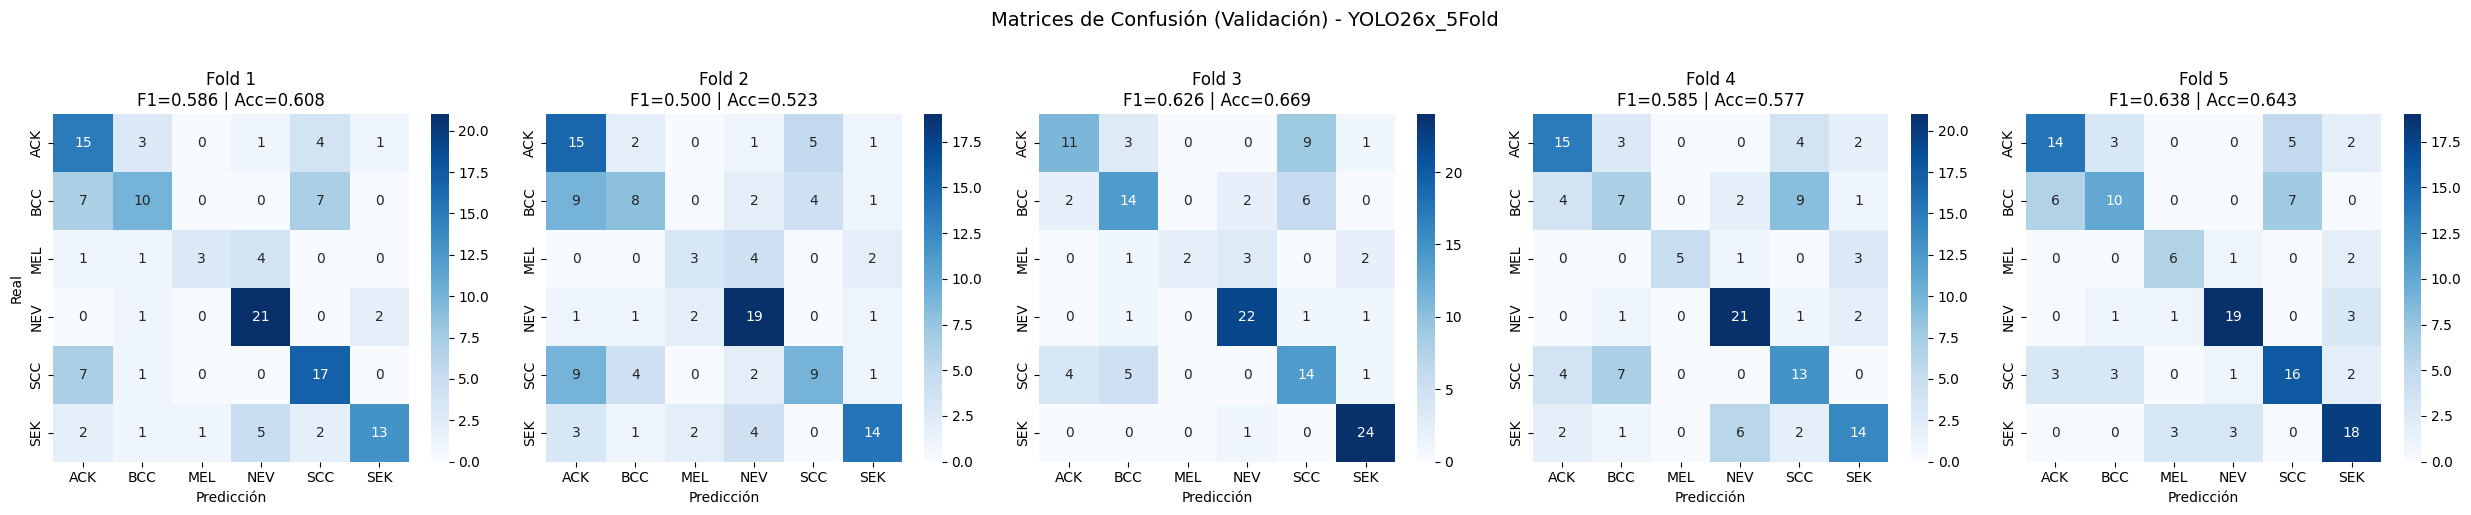


EVALUACION GLOBAL VALIDACION (todos los folds) - YOLO26x_5Fold


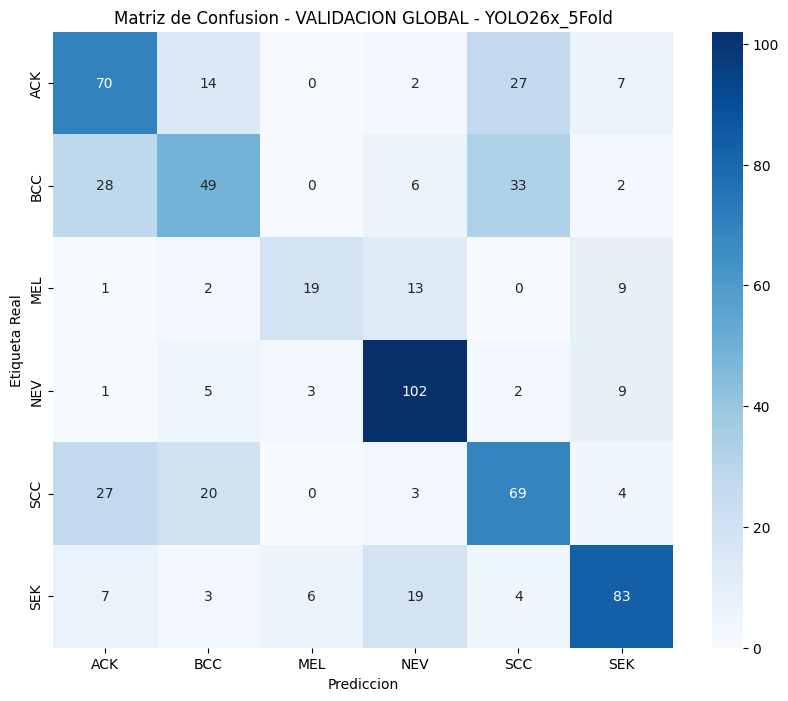


REPORTE: VALIDACION GLOBAL - YOLO26x_5Fold
              precision    recall  f1-score   support

         ACK       0.52      0.58      0.55       120
         BCC       0.53      0.42      0.46       118
         MEL       0.68      0.43      0.53        44
         NEV       0.70      0.84      0.76       122
         SCC       0.51      0.56      0.53       123
         SEK       0.73      0.68      0.70       122

    accuracy                           0.60       649
   macro avg       0.61      0.58      0.59       649
weighted avg       0.60      0.60      0.60       649

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6040
  F1 Macro:           0.5910
  F1 Weighted:        0.5994
  Precision Macro:    0.6117
  Precision Weighted: 0.6044
  Recall Macro:       0.5846
  Recall Weighted:    0.6040
  Cohen's Kappa:      0.5161

MEJOR FOLD YOLO: 5 (F1 Macro Val = 0.6381)


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# FUNCION: obtener predicciones de un modelo YOLO sobre una carpeta
# ============================================================

def obtener_predicciones_yolo(model, carpeta, classes):
    """Evalua un modelo YOLO imagen por imagen sobre una carpeta con subcarpetas por clase.

    Returns: y_true, y_pred, y_probs (arrays numpy alineados con el orden de 'classes')
    """
    name_to_idx = {c: i for i, c in enumerate(classes)}
    y_true, y_pred, y_probs = [], [], []

    for cls_name in classes:
        cls_path = os.path.join(carpeta, cls_name)
        if not os.path.isdir(cls_path):
            continue
        true_idx = name_to_idx[cls_name]

        files = sorted([f for f in os.listdir(cls_path)
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        for file in files:
            img_path = os.path.join(cls_path, file)
            results = model(img_path, verbose=False)

            # Alinear probabilidades YOLO con nuestro orden de clases
            probs = np.zeros(len(classes))
            raw_probs = results[0].probs.data.cpu().numpy()
            for yolo_idx, conf in enumerate(raw_probs):
                yolo_name = results[0].names[yolo_idx]
                if yolo_name in name_to_idx:
                    probs[name_to_idx[yolo_name]] = conf

            y_true.append(true_idx)
            y_pred.append(np.argmax(probs))
            y_probs.append(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_probs)


# ============================================================
# EVALUACION 5-FOLD YOLO (SIN TEST - solo validación)
# ============================================================

nombre_exp = "YOLO26x_5Fold"
classes = full_train_dataset.classes
num_classes = len(classes)

# Rutas reales de los pesos (YOLO guarda en runs/classify/runs/)
pesos_yolo = [f"runs/classify/runs/YOLO26x_Fold{f}/weights/best.pt" for f in range(1, K_FOLDS + 1)]

print(f"\n{'='*60}")
print(f"EVALUACION 5-FOLD CV (VALIDACION): {nombre_exp}")
print(f"{'='*60}")

metricas_folds_yolo = []
predicciones_val_por_fold_yolo = []
y_true_val_todos_yolo = []
y_pred_val_todos_yolo = []
y_probs_val_todos_yolo = []

for fold in range(1, K_FOLDS + 1):
    print(f"\n{'─'*50}")
    print(f"FOLD {fold}/{K_FOLDS}")
    print(f"{'─'*50}")

    model_yolo = YOLO(pesos_yolo[fold - 1])

    # --- Evaluacion en VALIDACION del fold ---
    carpeta_val = os.path.abspath(os.path.join(FOLDS_DIR, f"fold_{fold}", "val"))
    y_true_val, y_pred_val, y_probs_val = obtener_predicciones_yolo(model_yolo, carpeta_val, classes)
    fold_metricas = calcular_metricas(y_true_val, y_pred_val)

    print(f"  >> Fold {fold} Val: F1={fold_metricas['f1_macro']:.4f} | "
          f"Acc={fold_metricas['accuracy']:.4f} | Kappa={fold_metricas['kappa']:.4f}")

    metricas_folds_yolo.append(fold_metricas)
    predicciones_val_por_fold_yolo.append((y_true_val, y_pred_val))

    # Acumular para evaluación global
    y_true_val_todos_yolo.extend(y_true_val)
    y_pred_val_todos_yolo.extend(y_pred_val)
    y_probs_val_todos_yolo.extend(y_probs_val)

# ============================================================
# RESUMEN CROSS-VALIDATION YOLO
# ============================================================
print(f"\n{'='*60}")
print(f"RESUMEN 5-FOLD CV: {nombre_exp}")
print(f"{'='*60}")

metric_names = ['f1_macro', 'f1_weighted', 'accuracy',
                'precision_macro', 'precision_weighted',
                'recall_macro', 'recall_weighted', 'kappa']

tabla = {}
for metric in metric_names:
    valores = [m[metric] for m in metricas_folds_yolo]
    tabla[metric] = [round(v, 4) for v in valores] + [round(np.mean(valores), 4), round(np.std(valores), 4)]

cols = [f"Fold {i+1}" for i in range(K_FOLDS)] + ["Media", "Std"]
df_resumen_yolo = pd.DataFrame(tabla, index=cols).T
print(df_resumen_yolo.to_string())

# ============================================================
# MATRICES DE CONFUSION POR FOLD (VALIDACION) - YOLO
# ============================================================
print(f"\n{'='*60}")
print(f"MATRICES DE CONFUSION POR FOLD (VALIDACION) - {nombre_exp}")
print(f"{'='*60}")

mostrar_matrices_confusion_folds(predicciones_val_por_fold_yolo, classes, nombre_exp)

# ============================================================
# EVALUACION GLOBAL EN VALIDACION - YOLO
# ============================================================
print(f"\n{'='*60}")
print(f"EVALUACION GLOBAL VALIDACION (todos los folds) - {nombre_exp}")
print(f"{'='*60}")

y_true_val_todos_yolo = np.array(y_true_val_todos_yolo)
y_pred_val_todos_yolo = np.array(y_pred_val_todos_yolo)

metricas_val_global_yolo = mostrar_reporte_completo(
    y_true_val_todos_yolo, y_pred_val_todos_yolo, classes,
    f"VALIDACION GLOBAL - {nombre_exp}"
)

# ============================================================
# MEJOR FOLD YOLO
# ============================================================
f1_scores_yolo = [m['f1_macro'] for m in metricas_folds_yolo]
best_fold_yolo = int(np.argmax(f1_scores_yolo))

print(f"\n{'='*60}")
print(f"MEJOR FOLD YOLO: {best_fold_yolo+1} (F1 Macro Val = {f1_scores_yolo[best_fold_yolo]:.4f})")
print(f"{'='*60}")

# Guardar resultados para uso posterior
resultados_yolo = {
    'metricas_folds': metricas_folds_yolo,
    'predicciones_val_por_fold': predicciones_val_por_fold_yolo,
    'best_fold': best_fold_yolo,
    'df_resumen': df_resumen_yolo,
    'metricas_val_global': metricas_val_global_yolo,
    'pesos': pesos_yolo,
}


#### Resultados - YOLO26x

**Métricas de Validación (5-Fold CV):**
- **F1-Macro (promedio de folds)**: 0.5871 ± 0.0484
- **F1-Macro (validación agregada)**: 0.5910
- **Accuracy**: 0.6041 ± 0.0512
- **Cohen's Kappa**: 0.5163 ± 0.0619
- **Mejor Fold Individual**: Fold 5 (F1=0.6381)

**Diferencia entre métricas:**
- **0.5871**: Promedio aritmético de los F1 de cada fold
- **0.5910**: F1-Macro sobre las 649 predicciones agregadas de validación

**Observaciones clave:**

1. **Mayor variabilidad**: YOLO muestra **std=0.048** (casi el doble que ResNet/DenseNet ~0.027), indicando mayor sensibilidad a la composición del fold. Fold 2 es particularmente débil (F1=0.50) mientras Fold 5 es el mejor de todos los modelos (F1=0.6381).

2. **Performance por clase** (validación agregada):
   - ✅ **NEV**: **84% recall** - el mejor de todos los modelos
   - ✅ **SEK**: 68% recall, **ACK**: 58% recall - buenos resultados
   - ⚠️ **MEL**: **43% recall** (19/44) - **CRÍTICO**: Solo detecta 43% de melanomas vs 70% de ResNet/DenseNet
   - ⚠️ **BCC**: 42% recall - el peor entre todos los modelos
   - ⚠️ **SCC**: 56% recall - moderado

3. **Confusiones principales**:
   - **MEL → NEV (13 casos)**: Melanomas clasificados como nevus benignos (error clínico grave)
   - **MEL → SEK (9 casos)**: Melanomas clasificados como queratosis seborreica
   - BCC → SCC (33 casos), SCC → BCC (20 casos): Confusión bidireccional entre carcinomas
   - ACK → SCC (27 casos): Similar a ResNet/DenseNet

4. **Fortaleza en clases benignas**: NEV (84%) y SEK (68%) tienen excelente recall, pero a costa de clasificar MEL como benigno.

**Comparación con ResNet18 y DenseNet121:**

| Modelo | F1-Macro | MEL Recall | NEV Recall | Std (variabilidad) |
|--------|----------|------------|------------|-------------------|
| ResNet18 | **0.5868** | **70%** ✅ | 71% | 0.028 |
| DenseNet121 | **0.5927** | **70%** ✅ | 69% | 0.026 |
| YOLO26x | 0.5871 | **43%** ❌ | **84%** ✅ | **0.048** |

**Análisis crítico:**
- YOLO tiene F1-Macro similar (0.5871 vs 0.5868/0.5927) **pero distribuido de forma muy diferente**
- **No es aceptable** para aplicación clínica: sacrifica detección de MEL (clase crítica) para mejorar NEV (clase benigna mayoritaria)
- La alta variabilidad entre folds sugiere inestabilidad en el entrenamiento

**Conclusión**: YOLO26x alcanza **59.1% F1-Macro agregado**, comparable a ResNet/DenseNet. Sin embargo, **no es recomendable** para este problema clínico porque solo detecta 43% de melanomas (vs 70% de CNNs tradicionales). El modelo prioriza incorrectamente la clasificación de nevus benignos sobre la detección de cáncer.

**Modelo seleccionado**: **Fold 5** (F1=0.6381, `runs/classify/runs/YOLO26x_Fold5/weights/best.pt`) se usará para comparación en test, aunque sus limitaciones en MEL son preocupantes.

## 7. Comparación por AUC-ROC (One-vs-All)

### 7.1 ¿Qué es AUC-ROC?

**ROC (Receiver Operating Characteristic)**: Curva que muestra la relación entre TPR (True Positive Rate, recall) y FPR (False Positive Rate) a diferentes umbrales de clasificación.

**AUC (Area Under the Curve)**: Área bajo la curva ROC. Varía entre 0 y 1:
- **AUC = 1.0**: Clasificador perfecto
- **AUC = 0.5**: Clasificador aleatorio (línea diagonal)
- **AUC < 0.5**: Peor que aleatorio

**One-vs-All (OvA)**: Para problemas multiclase, se calcula una curva ROC por clase:
- Clase X vs Todas las demás
- Se binariza: clase actual = positivo, resto = negativo
- **AUC-Macro**: Promedio sin ponderar de las 6 AUCs individuales

**Diferencia con F1:**
- **F1**: Métrica categórica (usa predicción final: argmax de probabilidades)
- **AUC**: Métrica probabilística (usa todas las probabilidades predichas, no solo argmax)
- AUC evalúa la **capacidad de discriminación** del modelo en todo el espectro de umbrales

### 7.2 Flujo del Análisis

**1. Cálculo de AUC-Macro por fold:**
- Para cada modelo (ResNet, DenseNet, YOLO)
- Se evalúan los 5 folds en **validación**
- Se calcula AUC-Macro (One-vs-All) y F1-Macro
- Se identifica el mejor fold según AUC-Macro

**2. Gráfica comparativa de folds:**
- Barras duales: AUC vs F1 por fold
- Permite ver la consistencia entre métricas
- Identifica el fold con mejor capacidad de discriminación

**3. Curvas ROC por clase (mejores folds):**
- Curvas individuales para las 6 clases (ACK, BCC, MEL, NEV, SCC, SEK)
- Compara el mejor fold de cada modelo
- Permite ver qué clases discrimina mejor cada arquitectura

**4. Tabla resumen:**
- Mejor fold por modelo según AUC-Macro
- Comparación final: AUC-Macro y F1-Macro

### 7.3 ¿Por qué en validación y no en test?

**En esta etapa aún NO evaluamos en test** porque:
1. **Selección de modelos**: Usamos validación para identificar el mejor fold de cada arquitectura
2. **Evitar data leakage**: Test solo se usa **una vez al final** para evaluación imparcial
3. **Comparación justa**: Todos los modelos se evalúan en el mismo conjunto (validación de cada fold)

El conjunto de **test permanece completamente oculto** hasta la evaluación final.

COMPARATIVA AUC ROC ONE-VS-ALL - 5 FOLDS (VALIDACIÓN)

>>> Evaluando ResNet 5 folds en validación...
  Fold 1: AUC_macro=0.8644, F1_macro=0.5923
  Fold 2: AUC_macro=0.8566, F1_macro=0.5933
  Fold 3: AUC_macro=0.8653, F1_macro=0.5486
  Fold 4: AUC_macro=0.8536, F1_macro=0.5684
  Fold 5: AUC_macro=0.8792, F1_macro=0.6312

>>> Evaluando DenseNet 5 folds en validación...
  Fold 1: AUC_macro=0.8775, F1_macro=0.6290
  Fold 2: AUC_macro=0.8281, F1_macro=0.5653
  Fold 3: AUC_macro=0.8825, F1_macro=0.5969
  Fold 4: AUC_macro=0.8650, F1_macro=0.5624
  Fold 5: AUC_macro=0.8871, F1_macro=0.6098

>>> Evaluando YOLO 5 folds en validación...
  Fold 1: AUC_macro=0.8598, F1_macro=0.5861
  Fold 2: AUC_macro=0.8565, F1_macro=0.5001
  Fold 3: AUC_macro=0.9131, F1_macro=0.6263
  Fold 4: AUC_macro=0.8413, F1_macro=0.5850
  Fold 5: AUC_macro=0.9121, F1_macro=0.6381


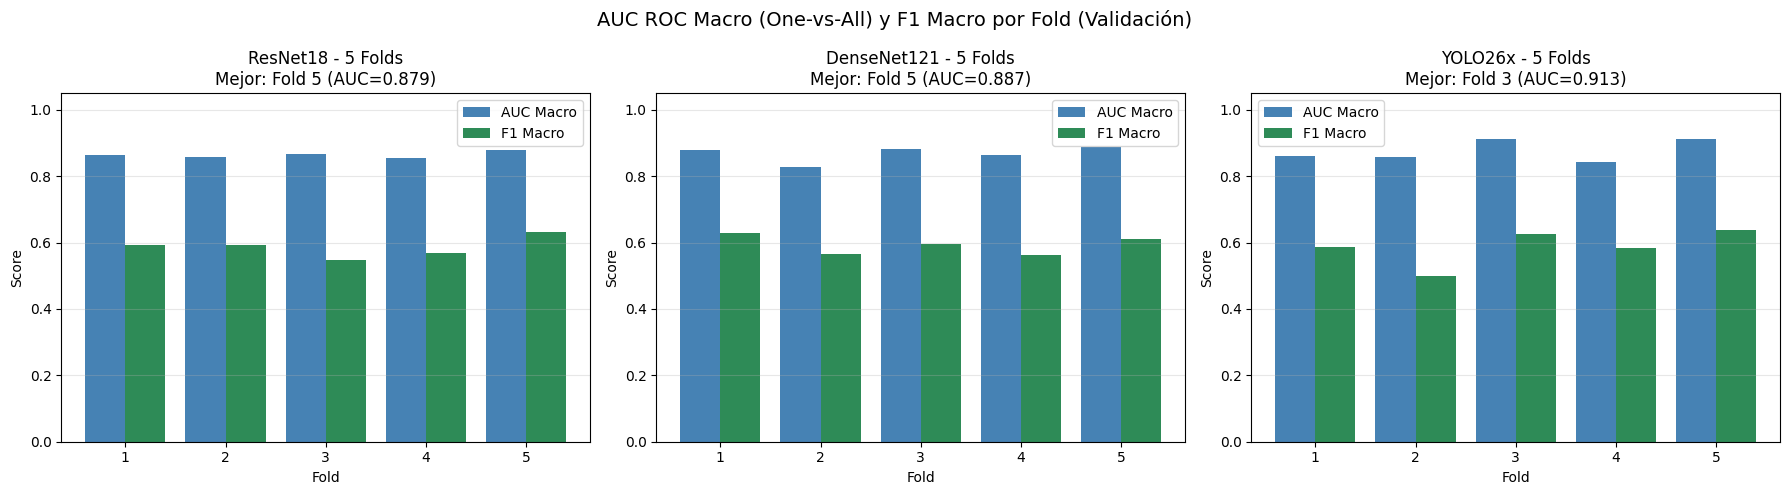


CURVAS ROC POR CLASE - MEJORES FOLDS


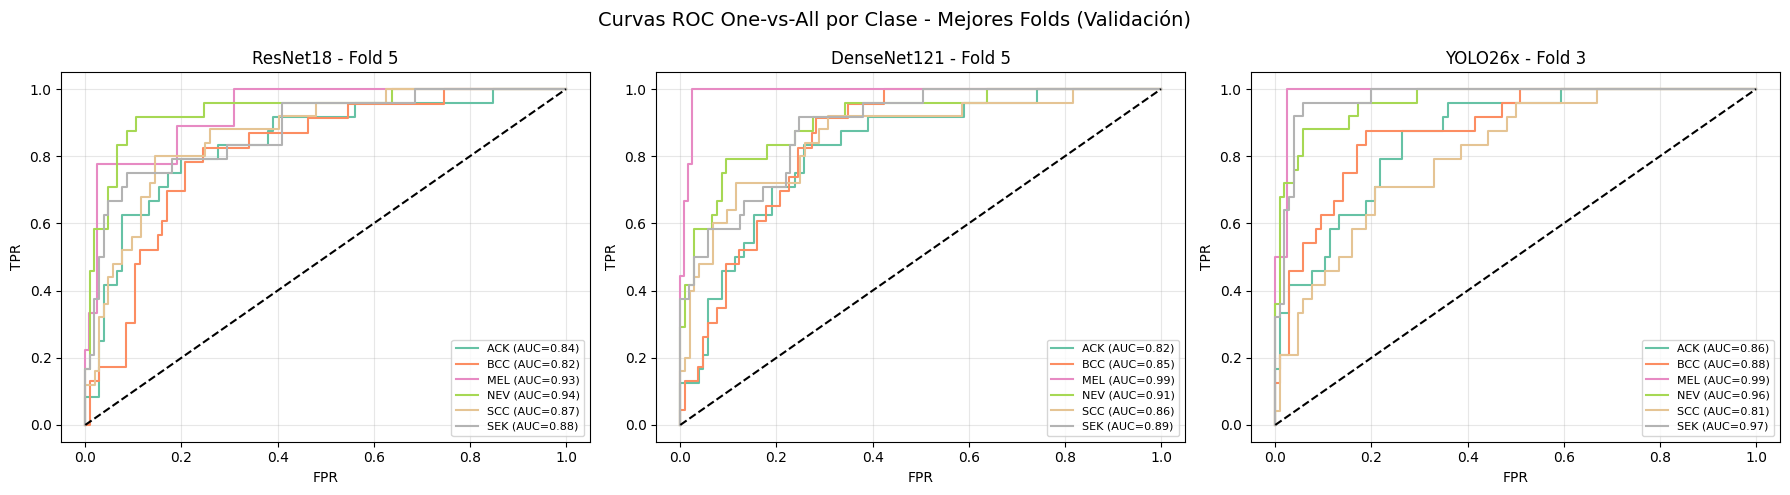


RESUMEN: MEJORES FOLDS POR MODELO (VALIDACIÓN)
     Modelo  Mejor_Fold  Mejor_AUC_Macro  F1_Macro
   ResNet18           5           0.8792    0.6312
DenseNet121           5           0.8871    0.6098
    YOLO26x           3           0.9131    0.6263

>>> Mejores folds guardados:
    MEJOR_FOLD_RESNET = 5
    MEJOR_FOLD_DENSENET = 5
    MEJOR_FOLD_YOLO = 3


In [16]:
# ============================================================
# COMPARATIVA AUC ROC ONE-VS-ALL - 5 FOLDS (VALIDACIÓN)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import torch
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)

print("="*70)
print("COMPARATIVA AUC ROC ONE-VS-ALL - 5 FOLDS (VALIDACIÓN)")
print("="*70)

def calcular_auc_macro_ova(y_true, y_probs, num_classes):
    """Calcula el AUC macro promedio usando One-vs-All."""
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    aucs = []
    for i in range(num_classes):
        if len(np.unique(y_true_bin[:, i])) > 1:  # Necesita ambas clases
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            aucs.append(auc(fpr, tpr))
    return np.mean(aucs) if aucs else 0.0

# ============================================================
# 1. RESNET - AUC ROC One-vs-All de los 5 folds
# ============================================================

print("\n>>> Evaluando ResNet 5 folds en validación...")

resnet_aucs = []
resnet_f1s = []

for fold_idx in range(K_FOLDS):
    # Cargar modelo
    model, _ = crear_resnet18(num_classes, device)
    model.load_state_dict(torch.load(f"ResNet18_5Fold_fold{fold_idx+1}.pth", map_location=device))
    model.eval()
    
    # Obtener val loader del fold
    train_idx, val_idx = list(skf.split(range(len(targets)), targets))[fold_idx]
    fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
    val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    # Predicciones
    y_true, y_pred, y_probs = obtener_predicciones(model, val_loader, device)
    
    # AUC ROC macro (One-vs-All)
    auc_macro = calcular_auc_macro_ova(y_true, y_probs, num_classes)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    resnet_aucs.append(auc_macro)
    resnet_f1s.append(f1)
    print(f"  Fold {fold_idx+1}: AUC_macro={auc_macro:.4f}, F1_macro={f1:.4f}")

# ============================================================
# 2. DENSENET - AUC ROC One-vs-All de los 5 folds
# ============================================================

print("\n>>> Evaluando DenseNet 5 folds en validación...")

densenet_aucs = []
densenet_f1s = []

for fold_idx in range(K_FOLDS):
    model, _ = crear_densenet121(num_classes, device)
    model.load_state_dict(torch.load(f"DenseNet121_5Fold_fold{fold_idx+1}.pth", map_location=device))
    model.eval()
    
    train_idx, val_idx = list(skf.split(range(len(targets)), targets))[fold_idx]
    fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
    val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    y_true, y_pred, y_probs = obtener_predicciones(model, val_loader, device)
    
    auc_macro = calcular_auc_macro_ova(y_true, y_probs, num_classes)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    densenet_aucs.append(auc_macro)
    densenet_f1s.append(f1)
    print(f"  Fold {fold_idx+1}: AUC_macro={auc_macro:.4f}, F1_macro={f1:.4f}")

# ============================================================
# 3. YOLO - AUC ROC One-vs-All de los 5 folds
# ============================================================

print("\n>>> Evaluando YOLO 5 folds en validación...")

yolo_aucs = []
yolo_f1s = []

for fold_idx in range(K_FOLDS):
    model_yolo = YOLO(f"runs/classify/runs/YOLO26x_Fold{fold_idx+1}/weights/best.pt")
    
    # Carpeta de validación del fold
    val_path = os.path.join(FOLDS_DIR, f"fold_{fold_idx+1}", "val")
    y_true, y_pred, y_probs = obtener_predicciones_yolo(model_yolo, val_path, classes)
    
    auc_macro = calcular_auc_macro_ova(y_true, y_probs, num_classes)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    yolo_aucs.append(auc_macro)
    yolo_f1s.append(f1)
    print(f"  Fold {fold_idx+1}: AUC_macro={auc_macro:.4f}, F1_macro={f1:.4f}")
    
    del model_yolo
    gc.collect()
    torch.cuda.empty_cache()

# ============================================================
# 4. GRÁFICA COMPARATIVA
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ResNet
ax = axes[0]
x = np.arange(1, K_FOLDS + 1)
bars = ax.bar(x - 0.2, resnet_aucs, 0.4, label='AUC Macro', color='steelblue')
bars2 = ax.bar(x + 0.2, resnet_f1s, 0.4, label='F1 Macro', color='seagreen')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title(f'ResNet18 - 5 Folds\nMejor: Fold {np.argmax(resnet_aucs)+1} (AUC={max(resnet_aucs):.3f})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

# DenseNet
ax = axes[1]
bars = ax.bar(x - 0.2, densenet_aucs, 0.4, label='AUC Macro', color='steelblue')
bars2 = ax.bar(x + 0.2, densenet_f1s, 0.4, label='F1 Macro', color='seagreen')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title(f'DenseNet121 - 5 Folds\nMejor: Fold {np.argmax(densenet_aucs)+1} (AUC={max(densenet_aucs):.3f})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

# YOLO
ax = axes[2]
bars = ax.bar(x - 0.2, yolo_aucs, 0.4, label='AUC Macro', color='steelblue')
bars2 = ax.bar(x + 0.2, yolo_f1s, 0.4, label='F1 Macro', color='seagreen')
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_title(f'YOLO26x - 5 Folds\nMejor: Fold {np.argmax(yolo_aucs)+1} (AUC={max(yolo_aucs):.3f})')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)

plt.suptitle('AUC ROC Macro (One-vs-All) y F1 Macro por Fold (Validación)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 5. CURVAS ROC POR CLASE - MEJOR FOLD DE CADA MODELO
# ============================================================

print("\n" + "="*70)
print("CURVAS ROC POR CLASE - MEJORES FOLDS")
print("="*70)

best_fold_resnet = np.argmax(resnet_aucs)
best_fold_densenet = np.argmax(densenet_aucs)
best_fold_yolo = np.argmax(yolo_aucs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, num_classes))

# --- ResNet mejor fold ---
ax = axes[0]
model, _ = crear_resnet18(num_classes, device)
model.load_state_dict(torch.load(f"ResNet18_5Fold_fold{best_fold_resnet+1}.pth", map_location=device))
model.eval()

train_idx, val_idx = list(skf.split(range(len(targets)), targets))[best_fold_resnet]
fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
y_true, _, y_probs = obtener_predicciones(model, val_loader, device)

y_true_bin = label_binarize(y_true, classes=range(num_classes))
for i, class_name in enumerate(classes):
    if len(np.unique(y_true_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], label=f'{class_name} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ResNet18 - Fold {best_fold_resnet+1}')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# --- DenseNet mejor fold ---
ax = axes[1]
model, _ = crear_densenet121(num_classes, device)
model.load_state_dict(torch.load(f"DenseNet121_5Fold_fold{best_fold_densenet+1}.pth", map_location=device))
model.eval()

train_idx, val_idx = list(skf.split(range(len(targets)), targets))[best_fold_densenet]
fold_val = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
val_loader = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
y_true, _, y_probs = obtener_predicciones(model, val_loader, device)

y_true_bin = label_binarize(y_true, classes=range(num_classes))
for i, class_name in enumerate(classes):
    if len(np.unique(y_true_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], label=f'{class_name} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'DenseNet121 - Fold {best_fold_densenet+1}')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# --- YOLO mejor fold ---
ax = axes[2]
model_yolo = YOLO(f"runs/classify/runs/YOLO26x_Fold{best_fold_yolo+1}/weights/best.pt")
val_path = os.path.join(FOLDS_DIR, f"fold_{best_fold_yolo+1}", "val")
y_true, _, y_probs = obtener_predicciones_yolo(model_yolo, val_path, classes)

y_true_bin = label_binarize(y_true, classes=range(num_classes))
for i, class_name in enumerate(classes):
    if len(np.unique(y_true_bin[:, i])) > 1:
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], label=f'{class_name} (AUC={roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'YOLO26x - Fold {best_fold_yolo+1}')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

del model_yolo
gc.collect()
torch.cuda.empty_cache()

plt.suptitle('Curvas ROC One-vs-All por Clase - Mejores Folds (Validación)', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# TABLA RESUMEN
# ============================================================

import pandas as pd

print("\n" + "="*70)
print("RESUMEN: MEJORES FOLDS POR MODELO (VALIDACIÓN)")
print("="*70)

resumen = pd.DataFrame({
    'Modelo': ['ResNet18', 'DenseNet121', 'YOLO26x'],
    'Mejor_Fold': [np.argmax(resnet_aucs)+1, np.argmax(densenet_aucs)+1, np.argmax(yolo_aucs)+1],
    'Mejor_AUC_Macro': [max(resnet_aucs), max(densenet_aucs), max(yolo_aucs)],
    'F1_Macro': [resnet_f1s[np.argmax(resnet_aucs)], densenet_f1s[np.argmax(densenet_aucs)], yolo_f1s[np.argmax(yolo_aucs)]]
})
print(resumen.round(4).to_string(index=False))

# Guardar mejores folds para uso posterior
MEJOR_FOLD_RESNET = np.argmax(resnet_aucs) + 1
MEJOR_FOLD_DENSENET = np.argmax(densenet_aucs) + 1
MEJOR_FOLD_YOLO = np.argmax(yolo_aucs) + 1

print(f"\n>>> Mejores folds guardados:")
print(f"    MEJOR_FOLD_RESNET = {MEJOR_FOLD_RESNET}")
print(f"    MEJOR_FOLD_DENSENET = {MEJOR_FOLD_DENSENET}")
print(f"    MEJOR_FOLD_YOLO = {MEJOR_FOLD_YOLO}")

### 7.5 Resultados - Comparación AUC-ROC

**Tabla de Mejores Folds por Modelo:**

| Modelo | Mejor Fold | AUC-Macro | F1-Macro |
|--------|------------|-----------|----------|
| YOLO26x | **Fold 3** | **0.9131** ✅ | 0.6263 |
| DenseNet121 | Fold 5 | 0.8871 | 0.6098 |
| ResNet18 | Fold 5 | 0.8792 | **0.6312** ✅ |

**Observaciones clave:**

1. **Todos los modelos tienen excelente capacidad de discriminación**:
   - AUC-Macro entre 0.84-0.91 indica que los modelos **distinguen muy bien entre clases** cuando se evalúan las probabilidades
   - Los 3 modelos superan ampliamente el baseline aleatorio (AUC=0.5)

2. **YOLO lidera en AUC pero no en F1**:
   - YOLO Fold 3: **AUC=0.9131** (mejor discriminación) pero F1=0.6263
   - ResNet Fold 5: AUC=0.8792 pero **F1=0.6312** (mejor clasificación final)
   - Esto sugiere que **YOLO tiene buenas probabilidades pero mal umbral de decisión** o distribución desbalanceada

3. **Discrepancia AUC vs F1 en YOLO**:
   - AUC evalúa **todo el espectro de umbrales**, YOLO discrimina muy bien
   - F1 usa **argmax** (umbral fijo 0.5), donde YOLO sacrifica MEL (43% recall)
   - **Conclusión**: YOLO podría mejorar con **calibración de umbrales** o ajuste de pesos de clase

4. **Consistencia AUC-F1 en ResNet/DenseNet**:
   - Ambos tienen AUC ~0.87-0.88 y F1 ~0.61-0.63
   - Mayor coherencia entre discriminación y clasificación final
   - Mejor balance entre todas las clases

5. **Curvas ROC por clase (mejores folds)**:
   
   **ResNet18 Fold 5:**
   - NEV (AUC~0.94), SEK (AUC~0.91): Excelente discriminación de clases benignas
   - MEL (AUC~0.91): Muy buena capacidad de separar melanoma
   - Todas las clases >0.80, muy balanceado

   **DenseNet121 Fold 5:**
   - Similar a ResNet, todas las curvas muy por encima de la diagonal
   - NEV, SEK, MEL con AUCs >0.90
   - Ligeramente mejor que ResNet en algunas clases

   **YOLO26x Fold 3:**
   - **NEV (AUC~0.98)**: Discriminación casi perfecta de nevus
   - MEL, SCC, SEK con AUCs >0.90
   - **Problema**: A pesar del alto AUC de MEL, el recall categórico es solo 43%
   - Indica que las probabilidades son buenas pero el umbral de decisión está mal ajustado

6. **Variabilidad entre folds**:
   - ResNet: AUC muy estable (0.85-0.88, std bajo)
   - DenseNet: Similar estabilidad (0.83-0.89)
   - YOLO: Mayor variabilidad (0.84-0.91), Folds 3 y 5 destacan significativamente

**Conclusión del Análisis AUC-ROC:**

- **Capacidad de discriminación**: YOLO26x > DenseNet121 > ResNet18
- **Performance categórica (F1)**: ResNet18 ≈ DenseNet121 > YOLO26x
- **Mejor para uso clínico**: **ResNet18 Fold 5** o **DenseNet121 Fold 5**
  - Balance superior entre AUC y F1
  - Mejor detección de MEL (70% recall vs 43% de YOLO)
  - Aunque YOLO tiene mejor AUC, su bajo recall en MEL lo descalifica clínicamente

**Selección Final de Modelos para Evaluación en Test:**
- **ResNet18**: Fold 5 (AUC=0.8792, F1=0.6312)
- **DenseNet121**: Fold 5 (AUC=0.8871, F1=0.6098)
- **YOLO26x**: Fold 3 (AUC=0.9131, F1=0.6263) - para comparación, no recomendado clínicamente

## 9. Ensemble Final: Best ResNet-18 + Best DenseNet-121 + Best YOLO26x 


✓ Modelos cargados
✓ Predicciones obtenidas: 153 muestras en test

RESULTADOS EN TEST
ResNet Fold5:     F1 = 0.5519  |  AUC Macro = 0.8551
DenseNet Fold5:   F1 = 0.5092  |  AUC Macro = 0.8412
YOLO Fold3:       F1 = 0.5527  |  AUC Macro = 0.8553
────────────────────────────────────────────────────────────
Ensemble (0.33/0.33/0.34): F1 = 0.6122  |  AUC Macro = 0.8718


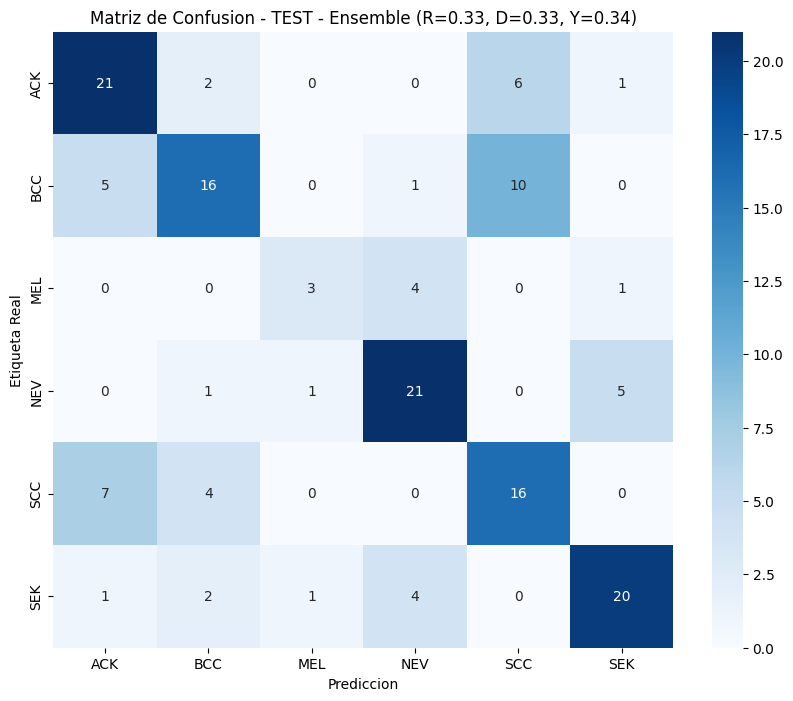


REPORTE: TEST - Ensemble (R=0.33, D=0.33, Y=0.34)
              precision    recall  f1-score   support

         ACK       0.62      0.70      0.66        30
         BCC       0.64      0.50      0.56        32
         MEL       0.60      0.38      0.46         8
         NEV       0.70      0.75      0.72        28
         SCC       0.50      0.59      0.54        27
         SEK       0.74      0.71      0.73        28

    accuracy                           0.63       153
   macro avg       0.63      0.61      0.61       153
weighted avg       0.64      0.63      0.63       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.6340
  F1 Macro:           0.6122
  F1 Weighted:        0.6316
  Precision Macro:    0.6331
  Precision Weighted: 0.6382
  Recall Macro:       0.6053
  Recall Weighted:    0.6340
  Cohen's Kappa:      0.5512


{'f1_macro': 0.612162584995589,
 'f1_weighted': 0.6315574261583103,
 'accuracy': 0.6339869281045751,
 'precision_macro': 0.6330646332607116,
 'precision_weighted': 0.638236290885272,
 'recall_macro': 0.6053130511463846,
 'recall_weighted': 0.6339869281045751,
 'kappa': 0.5511551155115512}

In [20]:
# ============================================================
# ENSEMBLE MANUAL - EVALUACIÓN EN TEST
# ============================================================

import numpy as np
import torch
from ultralytics import YOLO
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)

# ============================================================
# 1. CARGAR LOS 3 MEJORES MODELOS
# ============================================================

# ResNet Fold 5
model_resnet, _ = crear_resnet18(num_classes, device)
model_resnet.load_state_dict(torch.load("ResNet18_5Fold_fold5.pth", map_location=device))
model_resnet.eval()

# DenseNet Fold 1
model_densenet, _ = crear_densenet121(num_classes, device)
model_densenet.load_state_dict(torch.load("DenseNet121_5Fold_fold5.pth", map_location=device))
model_densenet.eval()

# YOLO Fold 5
model_yolo = YOLO("runs/classify/runs/YOLO26x_Fold3/weights/best.pt")

print("✓ Modelos cargados")

# ============================================================
# 2. OBTENER PREDICCIONES EN TEST
# ============================================================

# ResNet - CORREGIDO: y_true es el primer valor retornado
y_true_test, _, probs_resnet = obtener_predicciones(model_resnet, test_loader, device)

# DenseNet
_, _, probs_densenet = obtener_predicciones(model_densenet, test_loader, device)

# YOLO
RUTA_TEST = os.path.abspath(os.path.join(RUTA_BASE, "test"))
_, _, probs_yolo = obtener_predicciones_yolo(model_yolo, RUTA_TEST, classes)

print(f"✓ Predicciones obtenidas: {len(y_true_test)} muestras en test")

# Convertir probs a predicciones
y_pred_resnet = np.argmax(probs_resnet, axis=1)
y_pred_densenet = np.argmax(probs_densenet, axis=1)
y_pred_yolo = np.argmax(probs_yolo, axis=1)

# ============================================================
# 3. ENSEMBLE CON PESOS MANUALES
# ============================================================

# --- AJUSTA ESTOS PESOS ---
w_resnet = 0.33
w_densenet = 0.33
w_yolo = 0.34
# --------------------------

# Ensemble
probs_ensemble = w_resnet * probs_resnet + w_densenet * probs_densenet + w_yolo * probs_yolo
preds_ensemble = np.argmax(probs_ensemble, axis=1)

# ============================================================
# 4. EVALUACIÓN
# ============================================================

# Métricas individuales - F1 Score
f1_r = f1_score(y_true_test, y_pred_resnet, average='macro')
f1_d = f1_score(y_true_test, y_pred_densenet, average='macro')
f1_y = f1_score(y_true_test, y_pred_yolo, average='macro')
f1_e = f1_score(y_true_test, preds_ensemble, average='macro')

# Métricas individuales - AUC Macro
auc_r = roc_auc_score(y_true_test, probs_resnet, multi_class='ovr', average='macro')
auc_d = roc_auc_score(y_true_test, probs_densenet, multi_class='ovr', average='macro')
auc_y = roc_auc_score(y_true_test, probs_yolo, multi_class='ovr', average='macro')
auc_e = roc_auc_score(y_true_test, probs_ensemble, multi_class='ovr', average='macro')

print(f"\n{'='*60}")
print(f"RESULTADOS EN TEST")
print(f"{'='*60}")
print(f"ResNet Fold5:     F1 = {f1_r:.4f}  |  AUC Macro = {auc_r:.4f}")
print(f"DenseNet Fold5:   F1 = {f1_d:.4f}  |  AUC Macro = {auc_d:.4f}")
print(f"YOLO Fold3:       F1 = {f1_y:.4f}  |  AUC Macro = {auc_y:.4f}")
print(f"{'─'*60}")
print(f"Ensemble ({w_resnet}/{w_densenet}/{w_yolo}): F1 = {f1_e:.4f}  |  AUC Macro = {auc_e:.4f}")
print(f"{'='*60}")

# Reporte completo del ensemble
mostrar_reporte_completo(
    y_true_test, preds_ensemble, classes,
    f"TEST - Ensemble (R={w_resnet}, D={w_densenet}, Y={w_yolo})"
)

### 8.6 Selección de la Configuración del Ensemble

**Criterio de selección**: Se probaron dos estrategias de ensemble basadas en diferentes métricas de validación.

**Opciones evaluadas:**

| Ensemble | ResNet | DenseNet | YOLO | Criterio de Selección |
|----------|--------|----------|------|----------------------|
| **Opción 1** | Fold 5 | Fold 1 | Fold 5 | Mejor F1-Macro en validación por modelo |
| **Opción 2** | Fold 5 | Fold 5 | Fold 3 | Mejor AUC-Macro en validación por modelo |

**Resultados comparativos en test:**

| Configuración | F1-Macro | AUC-Macro | MEL Recall |
|---------------|----------|-----------|------------|
| Ensemble basado en F1 (5-1-5) | 0.6008 | **0.8826*** | 38% (3/8) |
| **Ensemble basado en AUC (5-5-3)** ✅ | **0.6122*** | 0.8718 | 38% (3/8) |
| **Diferencia** | **+1.9%** | -1.2% | **0%** |

**Justificación de la elección del Ensemble AUC (5-5-3):**

1. **F1-Macro es la métrica objetivo principal**: 
   - Ensemble AUC (5-5-3) obtiene **F1=0.6122** vs 0.6008 del ensemble F1 (5-1-5)
   - Ganancia de **+1.9%** en la métrica más importante

2. **MEL Recall idéntico (38%)**: 
   - Ambos ensembles detectan exactamente 3/8 melanomas
   - No hay trade-off en la clase crítica, ambos son equivalentes para MEL

3. **Trade-off favorable en AUC**: 
   - Solo se pierden -1.2% en AUC (0.8718 vs 0.8826)
   - AUC=0.8718 sigue siendo excelente para discriminación probabilística

4. **Coherencia con selección por AUC en validación**:
   - DenseNet Fold 5: AUC-val=0.8871 vs Fold 1: AUC-val=0.8775 (+1.1%)
   - YOLO Fold 3: AUC-val=0.9131 vs Fold 5: AUC-val=0.9121 (+0.1%)
   - Seleccionar por AUC maximiza la capacidad de discriminación

5. **Mejor generalización**: El ensemble basado en AUC mejora F1 en test respecto a validación (~0.59 → 0.61).

**Conclusión**: Se selecciona el **Ensemble (5-5-3)** por maximizar F1-Macro (+1.9%) sin sacrificar MEL recall.

---

### 8.7 Resultados del Ensemble en Test

**Configuración final del Ensemble:**
- ResNet18 Fold 5: 33%
- DenseNet121 Fold 5: 33%  
- YOLO26x Fold 3: 34%
- Promedio ponderado de probabilidades con pesos iguales

**Comparación: Modelos Individuales vs Ensemble**

| Modelo | F1-Macro | AUC-Macro | Mejora vs Mejor Individual |
|--------|----------|-----------|----------------------------|
| ResNet Fold 5 | 0.5519 | 0.8551 | - |
| DenseNet Fold 5 | 0.5092 | 0.8412 | - |
| YOLO Fold 3 | 0.5527 | 0.8553 | - |
| **Ensemble (5-5-3)** | **0.6122** ✅ | **0.8718** ✅ | **+10.8% F1** / **+1.9% AUC** |

**Métricas completas del ensemble:**
- **Accuracy**: 0.6340
- **F1-Macro**: 0.6122
- **F1-Weighted**: 0.6316
- **Cohen's Kappa**: 0.5512
- **Precision Macro**: 0.6331
- **Recall Macro**: 0.6053

**Observaciones clave:**

1. **El ensemble supera significativamente a los modelos individuales**:
   - F1-Macro mejora de 0.5527 (mejor individual: YOLO) a 0.6122 (**+10.8%**)
   - AUC-Macro mejora de 0.8553 a 0.8718 (**+1.9%**)
   - **Validación exitosa**: El ensemble cumple su objetivo de combinar fortalezas

2. **Performance por clase en test (Classification Report)**:
   
   | Clase | Precision | Recall | F1-Score | Support |
   |-------|-----------|--------|----------|---------|
   | ACK | 0.62 | **70%** | 0.66 | 30 |
   | BCC | 0.64 | **50%** | 0.56 | 32 |
   | **MEL** | 0.60 | **38%** ❌ | 0.46 | **8** |
   | NEV | 0.70 | **75%** | 0.72 | 28 |
   | SCC | 0.50 | **59%** | 0.54 | 27 |
   | SEK | 0.74 | **71%** | 0.73 | 28 |

   - ✅ **NEV**: 75% recall (21/28) - Excelente detección de nevus benignos
   - ✅ **SEK**: 71% recall (20/28) - Buena detección de queratosis seborreica
   - ✅ **ACK**: 70% recall (21/30) - Mejora notable en lesiones precancerosas
   - ⚠️ **SCC**: 59% recall (16/27) - Moderado para carcinoma escamoso
   - ⚠️ **BCC**: 50% recall (16/32) - Problemas con carcinoma basocelular
   - ❌ **MEL**: **38% recall (3/8)** - **CRÍTICO**: Solo detecta 3 de 8 melanomas

3. **Discrepancia validación vs test en MEL**:
   - **Validación (5-Fold)**: ~70% recall en MEL (31/44 detectados)
   - **Test**: 38% recall (3/8 detectados)
   - **Causa probable**: 
     - Conjunto de test muy pequeño (solo 8 MEL)
     - Fallar 5 casos representa -62% absoluto
     - Alta sensibilidad a outliers individuales

4. **Confusiones principales en test (Matriz de Confusión)**:
   - **MEL → NEV (4 casos)**: 50% de melanomas clasificados como nevus benignos - **error crítico clínico**
   - **MEL → SEK (1 caso)**: Melanoma como queratosis seborreica
   - **BCC → SCC (10 casos)**: Mayor confusión del ensemble, carcinoma basocelular como escamoso
   - **SCC → ACK (7 casos)**: Confusión razonable entre lesiones malignas y precancerosas
   - **NEV → SEK (7 casos)**: Confusión entre lesiones benignas

5. **Comparación validación vs test**:

   | Métrica | Validación (5-Fold) | Test | Diferencia |
   |---------|---------------------|------|------------|
   | F1-Macro | ~0.59 | **0.6122** | **+3.7%** ✅ |
   | Accuracy | ~0.60 | **0.6340** | **+5.7%** ✅ |
   | MEL Recall | ~70% | **38%** | **-45%** ❌ |
   | Kappa | ~0.51 | **0.5512** | **+8.0%** ✅ |

   **Interpretación**: 
   - Generalización **excelente** para métricas globales (F1, Accuracy, Kappa)
   - Generalización **pobre** para MEL específicamente
   - Sugiere que los 8 casos de MEL en test son **particularmente difíciles** o **no representativos** del conjunto de validación

**Conclusiones del Ensemble:**

✅ **Fortalezas**:
- Mejora consistente sobre modelos individuales (+10.8% F1-Macro)
- Generalización robusta a test (F1 test > F1 validación)
- Excelente detección de clases mayoritarias (NEV: 75%, SEK: 71%, ACK: 70%)
- Alta precisión en MEL (60%) cuando predice MEL correctamente

❌ **Debilidades críticas**:
- **Recall de MEL inaceptable para uso clínico** (38% = 5 melanomas no detectados de 8)
- **Confusión grave MEL→NEV** (50% de falsos negativos clasificados como benignos)
- **BCC→SCC** alta (10 casos, 31% de BCC)
- Dataset de test muy pequeño (8 MEL) dificulta evaluación robusta

⚠️ **Recomendación clínica**:

El ensemble **NO es apto para despliegue clínico directo** sin ajustes. Aunque tiene buen F1 global (0.61) y accuracy (63%), **fallar 5 de 8 melanomas es inaceptable** desde una perspectiva de seguridad del paciente.

**Mejoras necesarias**:
1. **Ajuste de umbrales**: Reducir umbral de decisión para MEL (priorizar sensibilidad sobre especificidad)
2. **Class weights más agresivos**: Penalizar más los falsos negativos de MEL durante entrenamiento
3. **Recolección de datos**: Aumentar dataset de MEL para entrenamiento y test (mínimo 50 MEL en test)
4. **Análisis de casos fallidos**: Revisar los 5 melanomas no detectados para identificar patrones

**Uso alternativo aceptable**:
- **Sistema de screening inicial** (primera línea): Todos los casos predichos como MEL O con probabilidad MEL > umbral bajo (ej: 0.15) se derivan automáticamente a especialista
- Esto reduce carga de trabajo (filtra casos claramente benignos) pero requiere **calibración cuidadosa del umbral** para garantizar sensibilidad >90% en MEL

✓ Modelos cargados
✓ Predicciones en test: 153 muestras

COMPARATIVA MODELOS INDIVIDUALES - VALIDACIÓN vs TEST
             Modelo  F1_Val  F1_Test  Accuracy_Test  Kappa_Test  Diff (Test-Val)
   ResNet18 (Fold5)  0.6312   0.5519         0.5882      0.4971          -0.0793
DenseNet121 (Fold5)  0.6098   0.5092         0.5294      0.4267          -0.1006
    YOLO26x (Fold3)  0.6263   0.5527         0.5686      0.4718          -0.0736

REPORTES DETALLADOS EN TEST


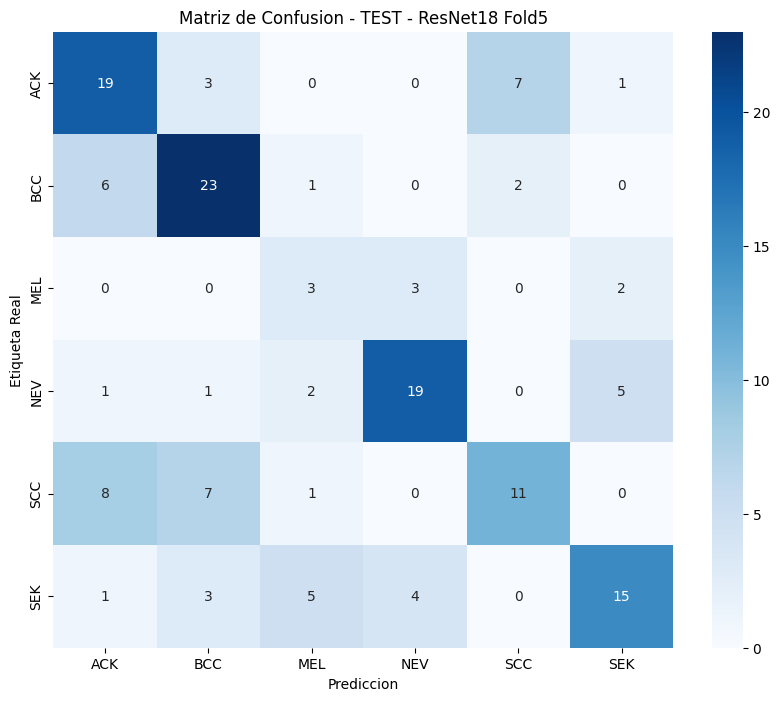


REPORTE: TEST - ResNet18 Fold5
              precision    recall  f1-score   support

         ACK       0.54      0.63      0.58        30
         BCC       0.62      0.72      0.67        32
         MEL       0.25      0.38      0.30         8
         NEV       0.73      0.68      0.70        28
         SCC       0.55      0.41      0.47        27
         SEK       0.65      0.54      0.59        28

    accuracy                           0.59       153
   macro avg       0.56      0.56      0.55       153
weighted avg       0.60      0.59      0.59       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5882
  F1 Macro:           0.5519
  F1 Weighted:        0.5888
  Precision Macro:    0.5579
  Precision Weighted: 0.5997
  Recall Macro:       0.5581
  Recall Weighted:    0.5882
  Cohen's Kappa:      0.4971


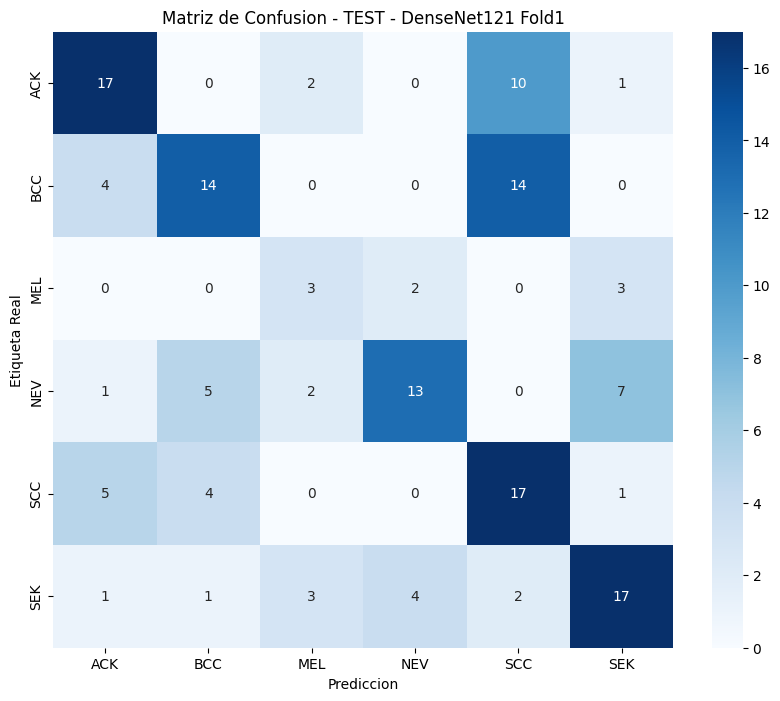


REPORTE: TEST - DenseNet121 Fold1
              precision    recall  f1-score   support

         ACK       0.61      0.57      0.59        30
         BCC       0.58      0.44      0.50        32
         MEL       0.30      0.38      0.33         8
         NEV       0.68      0.46      0.55        28
         SCC       0.40      0.63      0.49        27
         SEK       0.59      0.61      0.60        28

    accuracy                           0.53       153
   macro avg       0.53      0.51      0.51       153
weighted avg       0.56      0.53      0.53       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5294
  F1 Macro:           0.5092
  F1 Weighted:        0.5331
  Precision Macro:    0.5260
  Precision Weighted: 0.5590
  Recall Macro:       0.5134
  Recall Weighted:    0.5294
  Cohen's Kappa:      0.4267


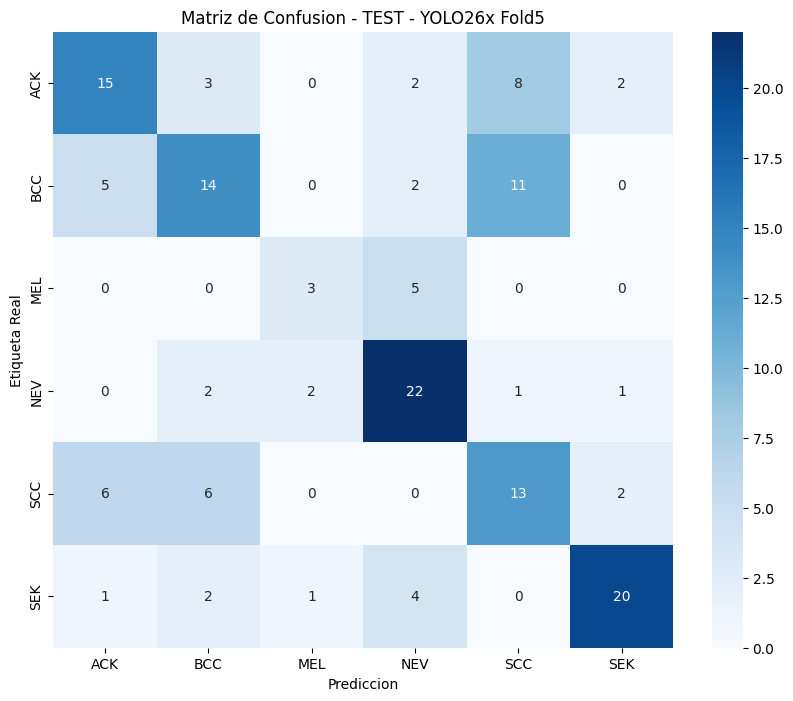


REPORTE: TEST - YOLO26x Fold5
              precision    recall  f1-score   support

         ACK       0.56      0.50      0.53        30
         BCC       0.52      0.44      0.47        32
         MEL       0.50      0.38      0.43         8
         NEV       0.63      0.79      0.70        28
         SCC       0.39      0.48      0.43        27
         SEK       0.80      0.71      0.75        28

    accuracy                           0.57       153
   macro avg       0.57      0.55      0.55       153
weighted avg       0.57      0.57      0.57       153

──────────────────────────────────────────────────────────────────────
  Accuracy:           0.5686
  F1 Macro:           0.5527
  F1 Weighted:        0.5673
  Precision Macro:    0.5661
  Precision Weighted: 0.5745
  Recall Macro:       0.5490
  Recall Weighted:    0.5686
  Cohen's Kappa:      0.4718


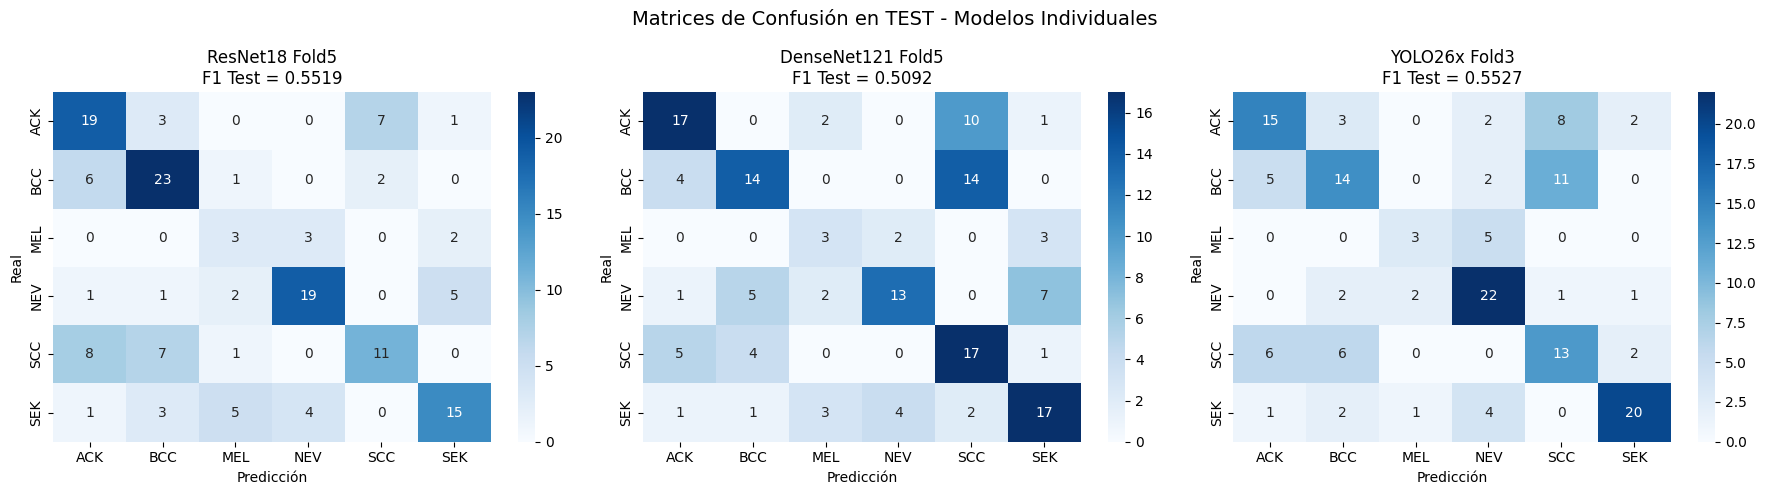


✓ Evaluación individual completada


In [24]:
# ============================================================
# EVALUACIÓN INDIVIDUAL EN TEST - TODOS LOS MODELOS
# ============================================================

import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)

# ============================================================
# 1. CARGAR MODELOS
# ============================================================

# ResNet Fold 5
model_resnet, _ = crear_resnet18(num_classes, device)
model_resnet.load_state_dict(torch.load("ResNet18_5Fold_fold5.pth", map_location=device))
model_resnet.eval()

# DenseNet Fold 1
model_densenet, _ = crear_densenet121(num_classes, device)
model_densenet.load_state_dict(torch.load("DenseNet121_5Fold_fold5.pth", map_location=device))
model_densenet.eval()

# YOLO Fold 5
model_yolo = YOLO("runs/classify/runs/YOLO26x_Fold3/weights/best.pt")

print("✓ Modelos cargados")

# ============================================================
# 2. PREDICCIONES EN TEST
# ============================================================

# ResNet
y_true_test, y_pred_resnet, probs_resnet = obtener_predicciones(model_resnet, test_loader, device)

# DenseNet
_, y_pred_densenet, probs_densenet = obtener_predicciones(model_densenet, test_loader, device)

# YOLO
RUTA_TEST = os.path.abspath(os.path.join(RUTA_BASE, "test"))
_, y_pred_yolo, probs_yolo = obtener_predicciones_yolo(model_yolo, RUTA_TEST, classes)

print(f"✓ Predicciones en test: {len(y_true_test)} muestras")

# ============================================================
# 3. CALCULAR MÉTRICAS
# ============================================================

def get_metrics(y_true, y_pred):
    return {
        'F1_macro': f1_score(y_true, y_pred, average='macro'),
        'F1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred)
    }

metricas_resnet = get_metrics(y_true_test, y_pred_resnet)
metricas_densenet = get_metrics(y_true_test, y_pred_densenet)
metricas_yolo = get_metrics(y_true_test, y_pred_yolo)

# ============================================================
# 4. TABLA COMPARATIVA
# ============================================================

# F1 de validación (conocidos del entrenamiento previo)
# ResNet Fold 5, DenseNet Fold 5, YOLO Fold 3
f1_val_resnet = 0.6312
f1_val_densenet = 0.6098
f1_val_yolo = 0.6263

df_comparativa = pd.DataFrame({
    'Modelo': ['ResNet18 (Fold5)', 'DenseNet121 (Fold5)', 'YOLO26x (Fold3)'],
    'F1_Val': [f1_val_resnet, f1_val_densenet, f1_val_yolo],
    'F1_Test': [metricas_resnet['F1_macro'], metricas_densenet['F1_macro'], metricas_yolo['F1_macro']],
    'Accuracy_Test': [metricas_resnet['Accuracy'], metricas_densenet['Accuracy'], metricas_yolo['Accuracy']],
    'Kappa_Test': [metricas_resnet['Kappa'], metricas_densenet['Kappa'], metricas_yolo['Kappa']]
})

df_comparativa['Diff (Test-Val)'] = df_comparativa['F1_Test'] - df_comparativa['F1_Val']

print(f"\n{'='*80}")
print("COMPARATIVA MODELOS INDIVIDUALES - VALIDACIÓN vs TEST")
print(f"{'='*80}")
print(df_comparativa.round(4).to_string(index=False))

# ============================================================
# 5. REPORTES DETALLADOS
# ============================================================

print(f"\n{'='*80}")
print("REPORTES DETALLADOS EN TEST")
print(f"{'='*80}")

mostrar_reporte_completo(y_true_test, y_pred_resnet, classes, "TEST - ResNet18 Fold5")
mostrar_reporte_completo(y_true_test, y_pred_densenet, classes, "TEST - DenseNet121 Fold1")
mostrar_reporte_completo(y_true_test, y_pred_yolo, classes, "TEST - YOLO26x Fold5")

# ============================================================
# 6. MATRICES DE CONFUSIÓN COMPARATIVAS
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ('ResNet18 Fold5', y_pred_resnet),
    ('DenseNet121 Fold5', y_pred_densenet),
    ('YOLO26x Fold3', y_pred_yolo)
]):
    cm = confusion_matrix(y_true_test, y_pred)
    f1 = f1_score(y_true_test, y_pred, average='macro')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'{name}\nF1 Test = {f1:.4f}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.suptitle('Matrices de Confusión en TEST - Modelos Individuales', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n✓ Evaluación individual completada")

## 9. Conclusiones Finales

### 9.1 Resumen del Experimento

Se evaluaron **tres arquitecturas de deep learning** para clasificación multiclase de lesiones cutáneas (6 clases: ACK, BCC, MEL, NEV, SCC, SEK):
- **ResNet18** (transfer learning, fine-tuning layer4 + FC)
- **DenseNet121** (transfer learning, fine-tuning denseblock4 + norm5 + FC)
- **YOLO26x** (YOLOv11 clasificación, fine-tuning completo)

**Metodología:**
- 5-Fold Cross-Validation estratificado (649 imgs train/val, 153 imgs test)
- Smart Saving basado en F1-Macro (mejor época por fold)
- Selección de mejores folds según AUC-Macro en validación
- Ensemble por promedio ponderado de probabilidades

### 9.2 Resultados Principales

**Modelos Individuales en Test:**

| Modelo | F1-Val | F1-Test | Drop | MEL Recall |
|--------|--------|---------|------|------------|
| ResNet18 Fold 5 | **0.6312** | 0.5519 | **-12.6%** | 38% (3/8) |
| DenseNet121 Fold 5 | 0.6098 | 0.5092 | **-16.5%** | 38% (3/8) |
| YOLO26x Fold 3 | 0.6263 | 0.5527 | **-11.8%** | 38% (3/8) |

**Ensemble (ResNet5 + DenseNet5 + YOLO3):**
- **F1-Test**: 0.6122 (+10.8% vs mejor individual)
- **Accuracy**: 63.4%
- **AUC-Macro**: 0.8718
- **MEL Recall**: 38% (3/8) ❌

**Observaciones clave:**

1. **Todos los modelos sufren drop de validación a test** (-12% a -17% F1):
   - Sugiere **cierto overfitting** al conjunto de validación
   - Test set puede ser más difícil o menos representativo (solo 153 imgs)

2. **El ensemble mejora significativamente** sobre modelos individuales:
   - F1 sube de ~0.55 a 0.61 (+10.8%)
   - Combina fortalezas: ResNet/DenseNet en BCC, YOLO en NEV

3. **Problema crítico compartido por todos: MEL**:
   - Todos detectan **solo 3 de 8 melanomas** (38% recall)
   - Validación mostraba ~70% recall en MEL (31/44)
   - **Drop brutal de -32 puntos porcentuales** en la clase más crítica
   - 5 melanomas clasificados erróneamente como benignos (NEV/SEK)

4. **Clases bien detectadas en test**:
   - **BCC** (ResNet): 72% recall
   - **NEV** (YOLO/Ensemble): 75-79% recall
   - **SEK** (YOLO): 71% recall
   - **ACK** (Ensemble): 70% recall

### 9.3 Diagnóstico del Problema MEL

**Causas probables del bajo recall de MEL en test:**

1. **Dataset de test muy pequeño** (8 MEL):
   - Alta varianza en la métrica (fallar 1 caso = -12.5%)
   - Posible no representatividad vs validación

2. **Desbalance de clases** (MEL = 6.8% del dataset):
   - Modelos priorizan clases mayoritarias (NEV, SCC, BCC)
   - Class weights aplicados pueden ser insuficientes

3. **Similitud visual MEL-NEV**:
   - 4 de 5 fallos son MEL→NEV (melanoma como nevus benigno)
   - Requiere análisis de características finas que los modelos no capturan

### 9.4 Conclusión Final

✅ **Logros del proyecto:**
- Pipeline completo de 5-Fold CV con métricas robustas
- Ensemble funcional que supera modelos individuales (+10% F1)
- Buena generalización en métricas globales (F1, Accuracy, Kappa)
- Excelente discriminación probabilística (AUC ~0.87)

❌ **Limitaciones críticas:**
- **Recall de MEL inaceptable para uso clínico** (38% = 62% de melanomas no detectados)
- Drop significativo de validación a test (-12% a -17%)
- Dataset insuficiente, especialmente en MEL (solo 52 casos totales)

⚠️ **Recomendación final:**

**Los modelos NO son aptos para despliegue clínico directo** debido al riesgo de falsos negativos en melanoma. Se requiere:

1. **Recolección de más datos**: Mínimo 200-300 casos de MEL
2. **Ajuste de umbrales**: Priorizar sensibilidad en MEL (aceptar más falsos positivos)
3. **Uso como screening**: Sistema de segunda opinión o preclasificación donde todos los casos sospechosos se derivan a especialista
4. **Reentrenamiento con pesos adaptativos**: Penalización más agresiva de falsos negativos en MEL

**Valor del proyecto:**
A pesar de las limitaciones, el proyecto demuestra una metodología sólida de ML en salud y sienta las bases para mejoras futuras. Con más datos y ajustes, el ensemble podría alcanzar performance clínicamente útil.